In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)

print("\nGPU Information:")
print(tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
NumPy version: 2.1.3
Pandas version: 2.2.3
Scikit-learn version: 1.6.1

GPU Information:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
import shutil
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# ==============================
# PROJECT CONFIGURATION
# ==============================

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 6
SEED = 42

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)
print("Random seed:", SEED)

Image size: 224
Batch size: 32
Number of classes: 6
Random seed: 42


In [4]:
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seeds configured.")

Random seeds configured.


In [5]:
# Create project directories

directories = [
    "/content/waste_project",
    "/content/waste_project/dataset",
    "/content/waste_project/models",
    "/content/waste_project/results",
    "/content/waste_project/results/graphs",
    "/content/waste_project/results/confusion_matrices",
    "/content/waste_project/results/metrics"
]

for directory in directories:
    os.makedirs(directory, exist_ok=True)

print("Project directories created successfully.")

Project directories created successfully.


In [6]:
for root, dirs, files in os.walk("/content/waste_project"):
    level = root.replace("/content/waste_project", "").count(os.sep)
    indent = "    " * level
    print(indent + os.path.basename(root) + "/")


waste_project/
    dataset/
    results/
        confusion_matrices/
        graphs/
        metrics/
    models/


In [7]:
# Download the resized TrashNet dataset

!wget -O /content/trashnet.zip \
"https://huggingface.co/datasets/garythung/trashnet/resolve/main/dataset-resized.zip"

print("Download completed!")

--2026-09-16 11:49:56--  https://huggingface.co/datasets/garythung/trashnet/resolve/main/dataset-resized.zip
Resolving huggingface.co (huggingface.co)... 3.163.189.90, 3.163.189.114, 3.163.189.37, ...
Connecting to huggingface.co (huggingface.co)|3.163.189.90|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/647949fffaa0a209531b9a2b/154a5f61da453c05242f7483d1ed8c1ccd55a3e81f6072629109f4b5fc891193?X-Xet-Cas-Uid=public&response-content-type=application%2Fzip&user_id=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27dataset-resized.zip%3B+filename%3D%22dataset-resized.zip%22%3B&Expires=1789562996&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjQ3OTQ5ZmZmYWEwYTIwOTUzMWI5YTJiLzE1NGE1ZjYxZGE0NTNjMDUyNDJmNzQ4M2QxZWQ4YzFjY2Q1NWEzZTgxZjYwNzI2MjkxMDlmNGI1ZmM4OTExOTNcXD9YLVhldC1DYXMtVWlkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LXR5cGU9KiZ1c2VyX2lkPXB1YmxpYyZyZXNwb25zZS1jb

In [8]:
import zipfile
import os

zip_path = "/content/trashnet.zip"
extract_path = "/content/waste_project/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [9]:
print("Contents of dataset folder:")
print(os.listdir("/content/waste_project/dataset"))


Contents of dataset folder:
['dataset-resized', '__MACOSX']


In [10]:
for root, dirs, files in os.walk("/content/waste_project/dataset"):
    level = root.replace("/content/waste_project/dataset", "").count(os.sep)
    indent = "    " * level
    print(indent + os.path.basename(root) + "/")

dataset/
    dataset-resized/
        trash/
        plastic/
        metal/
        glass/
        paper/
        cardboard/
    __MACOSX/
        dataset-resized/
            cardboard/


In [11]:
# Find the folder containing the TrashNet classes

expected_classes = {
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
}

dataset_path = None

for root, dirs, files in os.walk("/content/waste_project/dataset"):
    if expected_classes.issubset(set(dirs)):
        dataset_path = root
        break

print("Dataset path:")
print(dataset_path)

Dataset path:
/content/waste_project/dataset/dataset-resized


In [12]:
class_counts = {}

for class_name in sorted(expected_classes):
    class_folder = os.path.join(dataset_path, class_name)

    images = [
        f for f in os.listdir(class_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    class_counts[class_name] = len(images)

print("Number of images per class:\n")

for class_name, count in class_counts.items():
    print(f"{class_name:12s}: {count}")

print("\nTotal images:", sum(class_counts.values()))

Number of images per class:

cardboard   : 403
glass       : 501
metal       : 410
paper       : 594
plastic     : 482
trash       : 137

Total images: 2527


In [13]:
import matplotlib.pyplot as plt

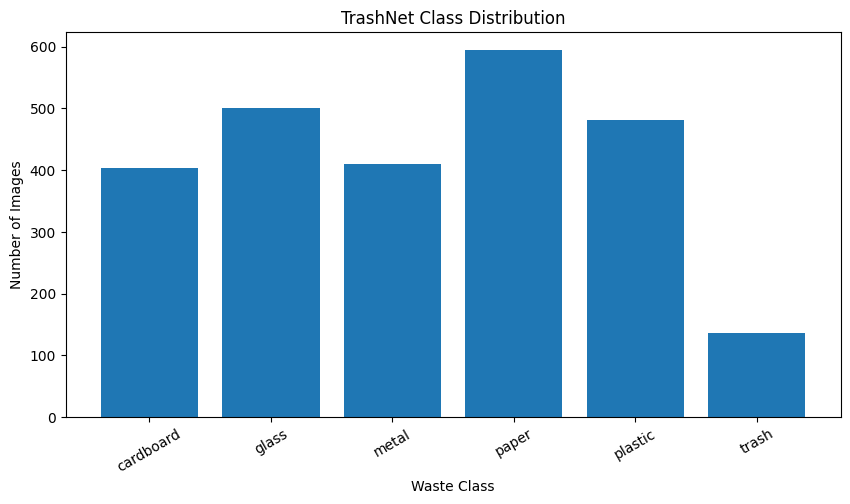

In [14]:
plt.figure(figsize=(10, 5))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.xlabel("Waste Class")
plt.ylabel("Number of Images")
plt.title("TrashNet Class Distribution")

plt.xticks(rotation=30)
plt.show()

In [15]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

print("Required libraries loaded successfully!")

Required libraries loaded successfully!


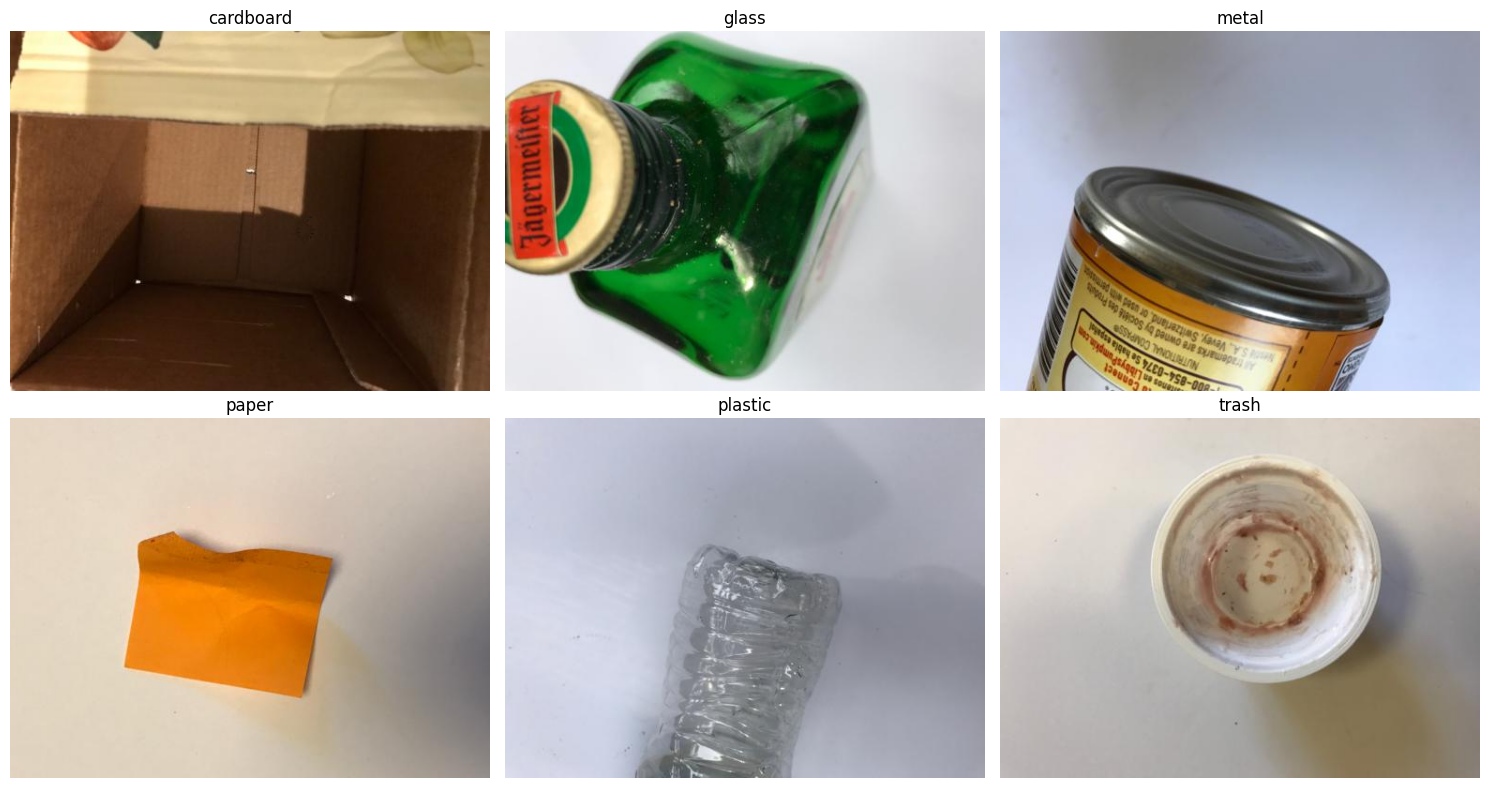

In [16]:
# Display one sample image from each class

class_names = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

plt.figure(figsize=(15, 8))

for i, class_name in enumerate(class_names):

    class_folder = os.path.join(dataset_path, class_name)

    image_files = [
        f for f in os.listdir(class_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Select a random image
    selected_image = random.choice(image_files)

    image_path = os.path.join(
        class_folder,
        selected_image
    )

    # Open image
    image = Image.open(image_path)

    # Display image
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
image_dimensions = {}

for class_name in class_names:

    class_folder = os.path.join(dataset_path, class_name)

    image_files = [
        f for f in os.listdir(class_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    dimensions = []

    for filename in image_files[:20]:
        image_path = os.path.join(class_folder, filename)

        with Image.open(image_path) as img:
            dimensions.append(img.size)

    image_dimensions[class_name] = dimensions

for class_name, dimensions in image_dimensions.items():
    print(f"\n{class_name}:")
    print(set(dimensions))


cardboard:
{(512, 384)}

glass:
{(512, 384)}

metal:
{(512, 384)}

paper:
{(512, 384)}

plastic:
{(512, 384)}

trash:
{(512, 384)}


In [18]:
corrupted_images = []

for class_name in class_names:

    class_folder = os.path.join(dataset_path, class_name)

    for filename in os.listdir(class_folder):

        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        image_path = os.path.join(class_folder, filename)

        try:
            with Image.open(image_path) as img:
                img.verify()

        except Exception:
            corrupted_images.append(image_path)

print("Number of corrupted images:", len(corrupted_images))

if corrupted_images:
    print("\nCorrupted files:")
    for image in corrupted_images:
        print(image)

Number of corrupted images: 0


In [19]:
print("Final dataset path:")
print(dataset_path)

print("\nClasses:")
print(class_names)

Final dataset path:
/content/waste_project/dataset/dataset-resized

Classes:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [20]:
# ==========================================
# FIX: DEFINE DATASET CLASSES
# ==========================================

class_names = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

print("Classes:")
print(class_names)
print("Number of classes:", len(class_names))

Classes:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of classes: 6


In [21]:
# ==========================================
# STEP 20: CREATE TRAIN / VALIDATION / TEST SPLIT
# ==========================================

import os
import shutil
import random

# Split ratios
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Output directory
split_base = "/content/waste_project/split_dataset"

# Create train, validation and test directories
for split in ["train", "validation", "test"]:

    for class_name in class_names:

        os.makedirs(
            os.path.join(split_base, split, class_name),
            exist_ok=True
        )

print("Split directories created successfully!")

Split directories created successfully!


In [22]:
print("Original dataset path:")
print(dataset_path)

Original dataset path:
/content/waste_project/dataset/dataset-resized


In [23]:
# ==========================================
# STEP 21: SPLIT IMAGES
# ==========================================

random.seed(SEED)

for class_name in class_names:

    # Original class folder
    class_folder = os.path.join(
        dataset_path,
        class_name
    )

    # Get image files
    image_files = [
        f for f in os.listdir(class_folder)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    # Shuffle images
    random.shuffle(image_files)

    # Total number of images
    total_images = len(image_files)

    # Calculate split points
    train_end = int(
        total_images * TRAIN_RATIO
    )

    val_end = train_end + int(
        total_images * VAL_RATIO
    )

    # Create splits
    train_files = image_files[:train_end]

    val_files = image_files[
        train_end:val_end
    ]

    test_files = image_files[
        val_end:
    ]

    # Copy training images
    for filename in train_files:

        source = os.path.join(
            class_folder,
            filename
        )

        destination = os.path.join(
            split_base,
            "train",
            class_name,
            filename
        )

        shutil.copy2(
            source,
            destination
        )

    # Copy validation images
    for filename in val_files:

        source = os.path.join(
            class_folder,
            filename
        )

        destination = os.path.join(
            split_base,
            "validation",
            class_name,
            filename
        )

        shutil.copy2(
            source,
            destination
        )

    # Copy testing images
    for filename in test_files:

        source = os.path.join(
            class_folder,
            filename
        )

        destination = os.path.join(
            split_base,
            "test",
            class_name,
            filename
        )

        shutil.copy2(
            source,
            destination
        )

    print(
        f"{class_name:12s} → "
        f"Train: {len(train_files):3d}, "
        f"Validation: {len(val_files):3d}, "
        f"Test: {len(test_files):3d}"
    )

print("\nDataset split completed successfully!")

cardboard    → Train: 282, Validation:  60, Test:  61
glass        → Train: 350, Validation:  75, Test:  76
metal        → Train: 287, Validation:  61, Test:  62
paper        → Train: 415, Validation:  89, Test:  90
plastic      → Train: 337, Validation:  72, Test:  73
trash        → Train:  95, Validation:  20, Test:  22

Dataset split completed successfully!


In [24]:
# ==========================================
# STEP 22: VERIFY DATASET SPLIT
# ==========================================

def count_images(folder):

    counts = {}

    for class_name in class_names:

        class_folder = os.path.join(
            folder,
            class_name
        )

        images = [
            f for f in os.listdir(class_folder)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png")
            )
        ]

        counts[class_name] = len(images)

    return counts


train_counts = count_images(
    os.path.join(
        split_base,
        "train"
    )
)

val_counts = count_images(
    os.path.join(
        split_base,
        "validation"
    )
)

test_counts = count_images(
    os.path.join(
        split_base,
        "test"
    )
)


print("========== TRAINING SET ==========")

for class_name in class_names:
    print(
        f"{class_name:12s}: "
        f"{train_counts[class_name]}"
    )

print(
    "Total:",
    sum(train_counts.values())
)


print("\n========== VALIDATION SET ==========")

for class_name in class_names:
    print(
        f"{class_name:12s}: "
        f"{val_counts[class_name]}"
    )

print(
    "Total:",
    sum(val_counts.values())
)


print("\n========== TEST SET ==========")

for class_name in class_names:
    print(
        f"{class_name:12s}: "
        f"{test_counts[class_name]}"
    )

print(
    "Total:",
    sum(test_counts.values())
)


total = (
    sum(train_counts.values())
    + sum(val_counts.values())
    + sum(test_counts.values())
)

print("\n================================")
print("TOTAL DATASET:", total)

========== TRAINING SET ==========
cardboard   : 282
glass       : 350
metal       : 287
paper       : 415
plastic     : 337
trash       : 95
Total: 1766

========== VALIDATION SET ==========
cardboard   : 60
glass       : 75
metal       : 61
paper       : 89
plastic     : 72
trash       : 20
Total: 377

========== TEST SET ==========
cardboard   : 61
glass       : 76
metal       : 62
paper       : 90
plastic     : 73
trash       : 22
Total: 384

TOTAL DATASET: 2527


In [25]:
# ==========================================
# STEP 23: CREATE TENSORFLOW DATASETS
# ==========================================

IMG_SIZE = 224
BATCH_SIZE = 32

train_dir = os.path.join(
    split_base,
    "train"
)

val_dir = os.path.join(
    split_base,
    "validation"
)

test_dir = os.path.join(
    split_base,
    "test"
)

print("Train directory:", train_dir)
print("Validation directory:", val_dir)
print("Test directory:", test_dir)

Train directory: /content/waste_project/split_dataset/train
Validation directory: /content/waste_project/split_dataset/validation
Test directory: /content/waste_project/split_dataset/test


In [26]:
# ==========================================
# STEP 24: LOAD DATASETS
# ==========================================

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nDatasets loaded successfully!")

Found 1766 files belonging to 6 classes.
Found 377 files belonging to 6 classes.
Found 384 files belonging to 6 classes.

Datasets loaded successfully!


In [27]:
# ==========================================
# STEP 25: CHECK CLASS ORDER
# ==========================================

print("Classes used by TensorFlow:")
print(train_dataset.class_names)

Classes used by TensorFlow:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [28]:
# ==========================================
# STEP 26: CHECK IMAGE AND LABEL SHAPES
# ==========================================

for images, labels in train_dataset.take(1):

    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

    print("\nImage data type:", images.dtype)
    print("Label data type:", labels.dtype)

    break

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)

Image data type: <dtype: 'float32'>
Label data type: <dtype: 'int32'>


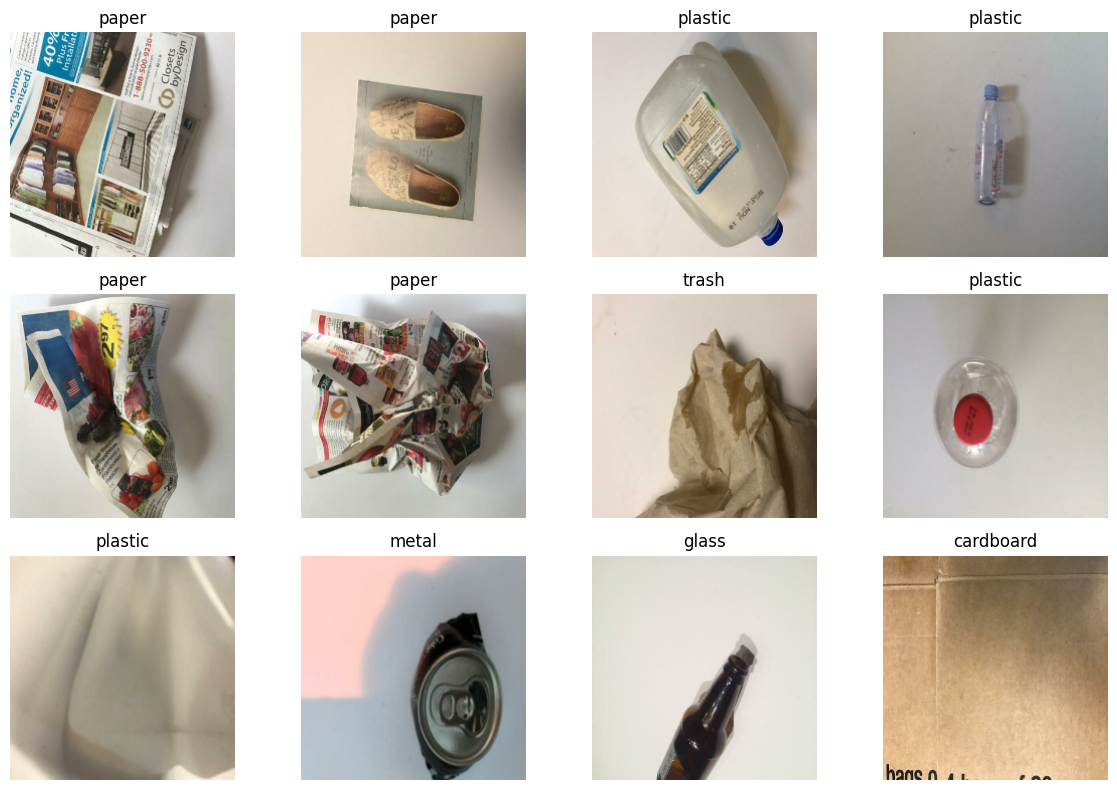

In [29]:
# ==========================================
# STEP 27: DISPLAY TRAINING IMAGES
# ==========================================

plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):

    for i in range(12):

        plt.subplot(3, 4, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            train_dataset.class_names[
                labels[i].numpy()
            ]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
# ==========================================
# STEP 28: OPTIMIZE DATA PIPELINE
# ==========================================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    buffer_size=AUTOTUNE
)

print("TensorFlow input pipeline optimized!")

TensorFlow input pipeline optimized!


In [31]:
# ==========================================
# STEP 30: BUILD BASELINE CNN
# ==========================================

from tensorflow.keras import layers, models

baseline_model = models.Sequential([

    # Input
    layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    # Normalize pixels
    layers.Rescaling(
        1.0 / 255
    ),

    # -------------------------
    # Convolution Block 1
    # -------------------------
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # -------------------------
    # Convolution Block 2
    # -------------------------
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # -------------------------
    # Convolution Block 3
    # -------------------------
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Convert feature maps to vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(
        128,
        activation="relu"
    ),

    # Output layer
    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

print("Baseline CNN created!")

Baseline CNN created!


In [32]:
# ==========================================
# STEP 30 — CHECK PROJECT VARIABLES
# ==========================================

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", class_names)
print("Number of classes:", len(class_names))

print("\nTraining dataset:", train_dataset)
print("Validation dataset:", validation_dataset)
print("Test dataset:", test_dataset)

Image size: 224
Batch size: 32
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of classes: 6

Training dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Test dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [33]:
# ==========================================
# STEP 30.1 — SET NUMBER OF CLASSES
# ==========================================

NUM_CLASSES = len(class_names)

print("NUM_CLASSES =", NUM_CLASSES)

NUM_CLASSES = 6


In [34]:
# ==========================================
# STEP 30.2 — IMPORT KERAS
# ==========================================

from tensorflow.keras import layers, models

print("Keras imported successfully!")

Keras imported successfully!


In [35]:
# ==========================================
# STEP 30.3 — BUILD BASELINE CNN
# ==========================================

baseline_model = models.Sequential([

    # Input
    layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    # Normalize pixels from 0-255 to 0-1
    layers.Rescaling(
        1.0 / 255
    ),

    # --------------------------------------
    # CONVOLUTION BLOCK 1
    # --------------------------------------
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # --------------------------------------
    # CONVOLUTION BLOCK 2
    # --------------------------------------
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # --------------------------------------
    # CONVOLUTION BLOCK 3
    # --------------------------------------
    layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # --------------------------------------
    # CLASSIFICATION
    # --------------------------------------

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

print("Baseline CNN created successfully!")

Baseline CNN created successfully!


In [36]:
# ==========================================
# STEP 30.4 — MODEL SUMMARY
# ==========================================

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,206 (49.36 MB)

 Trainable params: 12,939,206 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# ==========================================
# STEP 30.5 — COMPILE BASELINE CNN
# ==========================================

baseline_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        "accuracy"
    ]
)

print("Baseline CNN compiled successfully!")

Baseline CNN compiled successfully!


In [38]:
# ==========================================
# STEP 31 — TRAIN BASELINE CNN
# ==========================================

EPOCHS = 20

history_baseline = baseline_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 155ms/step - accuracy: 0.3375 - loss: 1.6934 - val_accuracy: 0.3740 - val_loss: 1.4787
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.4989 - loss: 1.3100 - val_accuracy: 0.4430 - val_loss: 1.3961
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.5680 - loss: 1.1263 - val_accuracy: 0.5570 - val_loss: 1.1939
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.6540 - loss: 0.9332 - val_accuracy: 0.5597 - val_loss: 1.2356
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.7157 - loss: 0.7773 - val_accuracy: 0.5915 - val_loss: 1.2898
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.7939 - loss: 0.5958 - val_accuracy: 0.5836 - val_loss: 1.4089
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.8409 - loss: 0.4663 - val_accuracy: 0.5597 - val_loss: 1.5450
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.8907 - loss: 0.3303 - val_accuracy: 0.5385 -

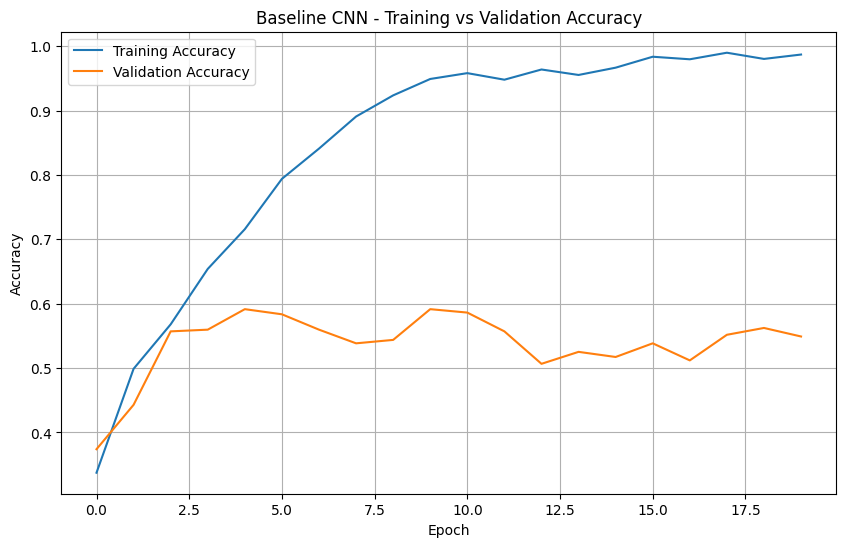

In [39]:
# ==========================================
# STEP 32 — BASELINE ACCURACY GRAPH
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_baseline.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_baseline.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Baseline CNN - Training vs Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

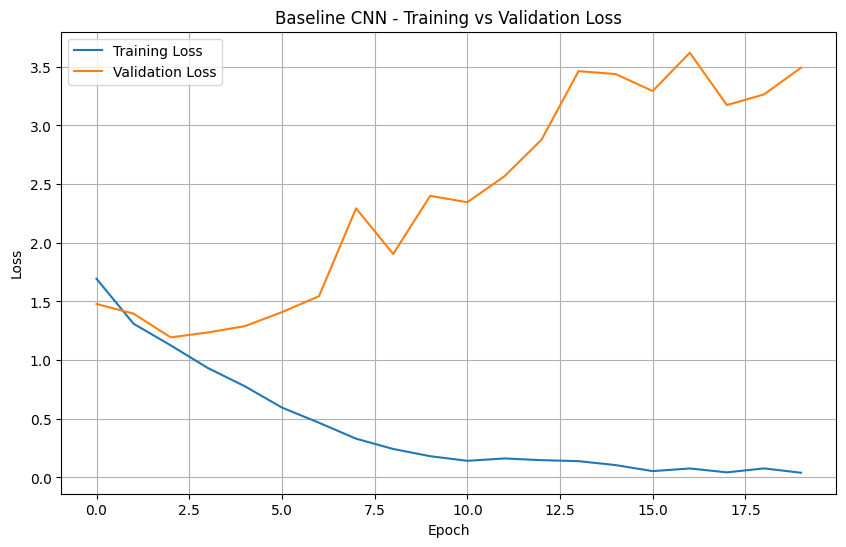

In [40]:
# ==========================================
# STEP 33 — BASELINE LOSS GRAPH
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_baseline.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_baseline.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Baseline CNN - Training vs Validation Loss"
)

plt.legend()
plt.grid(True)

plt.show()

In [41]:
# ==========================================
# STEP 34 — BASELINE TEST EVALUATION
# ==========================================

test_loss, test_accuracy = baseline_model.evaluate(
    test_dataset
)

print("\n================================")
print("BASELINE CNN RESULTS")
print("================================")

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5495 - loss: 3.2022

BASELINE CNN RESULTS
Test Loss     : 3.2022018432617188
Test Accuracy : 0.5494791865348816


In [42]:
# ==========================================
# STEP 35 — GENERATE BASELINE PREDICTIONS
# ==========================================

import numpy as np

y_true = []
y_pred = []
y_confidence = []

for images, labels in test_dataset:

    predictions = baseline_model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    confidence = np.max(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted_classes
    )

    y_confidence.extend(
        confidence
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_confidence = np.array(y_confidence)

print("Predictions generated!")
print("Number of test images:", len(y_true))

Predictions generated!
Number of test images: 384


In [43]:
# ==========================================
# STEP 36 — CLASSIFICATION REPORT
# ==========================================

from sklearn.metrics import classification_report

report_baseline = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report_baseline)

              precision    recall  f1-score   support

   cardboard     0.4891    0.7377    0.5882        61
       glass     0.5246    0.4211    0.4672        76
       metal     0.4912    0.4516    0.4706        62
       paper     0.6275    0.7111    0.6667        90
     plastic     0.5636    0.4247    0.4844        73
       trash     0.6471    0.5000    0.5641        22

    accuracy                         0.5495       384
   macro avg     0.5572    0.5410    0.5402       384
weighted avg     0.5521    0.5495    0.5425       384



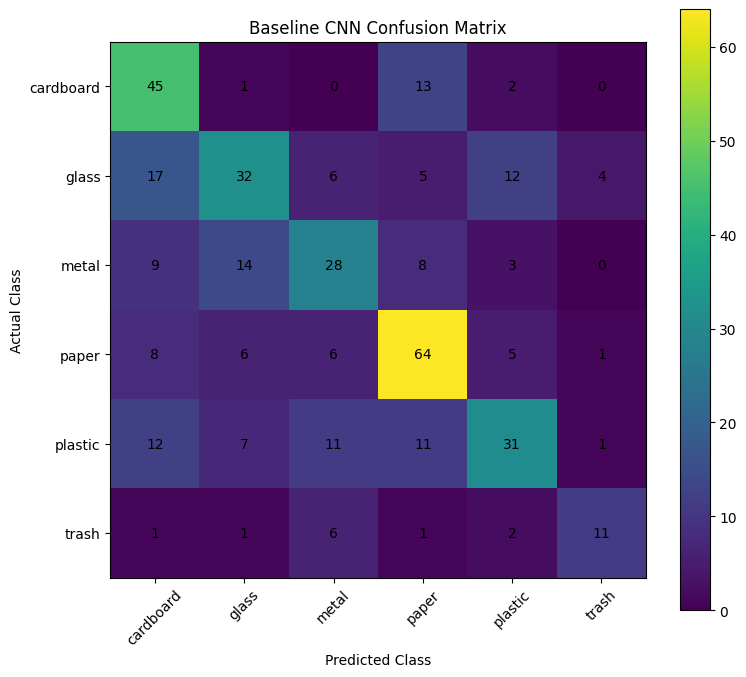

In [44]:
# ==========================================
# STEP 37 — BASELINE CONFUSION MATRIX
# ==========================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_baseline = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8, 7))

plt.imshow(cm_baseline)

plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=45
)

plt.yticks(
    range(NUM_CLASSES),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Baseline CNN Confusion Matrix"
)

for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        plt.text(
            j,
            i,
            cm_baseline[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [45]:
# ==========================================
# STEP 38 — SAVE BASELINE MODEL
# ==========================================

baseline_model.save(
    "/content/waste_project/baseline_cnn.keras"
)

print("Baseline model saved successfully!")

Baseline model saved successfully!


In [46]:
# ==========================================
# STEP 39 — STORE BASELINE METRICS
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

baseline_accuracy = accuracy_score(
    y_true,
    y_pred
)

baseline_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

baseline_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

baseline_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Baseline Accuracy :", baseline_accuracy)
print("Baseline Precision:", baseline_precision)
print("Baseline Recall   :", baseline_recall)
print("Baseline F1       :", baseline_f1)

Baseline Accuracy : 0.5494791666666666
Baseline Precision: 0.552117932890699
Baseline Recall   : 0.5494791666666666
Baseline F1       : 0.54253152232996


In [47]:
# ==========================================
# STEP 40 — STANDARD DATA AUGMENTATION
# ==========================================

standard_augmentation = tf.keras.Sequential([

    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomRotation(
        0.10
    ),

    layers.RandomZoom(
        0.10
    ),

    layers.RandomContrast(
        0.10
    )
])

print("Standard augmentation created!")

Standard augmentation created!


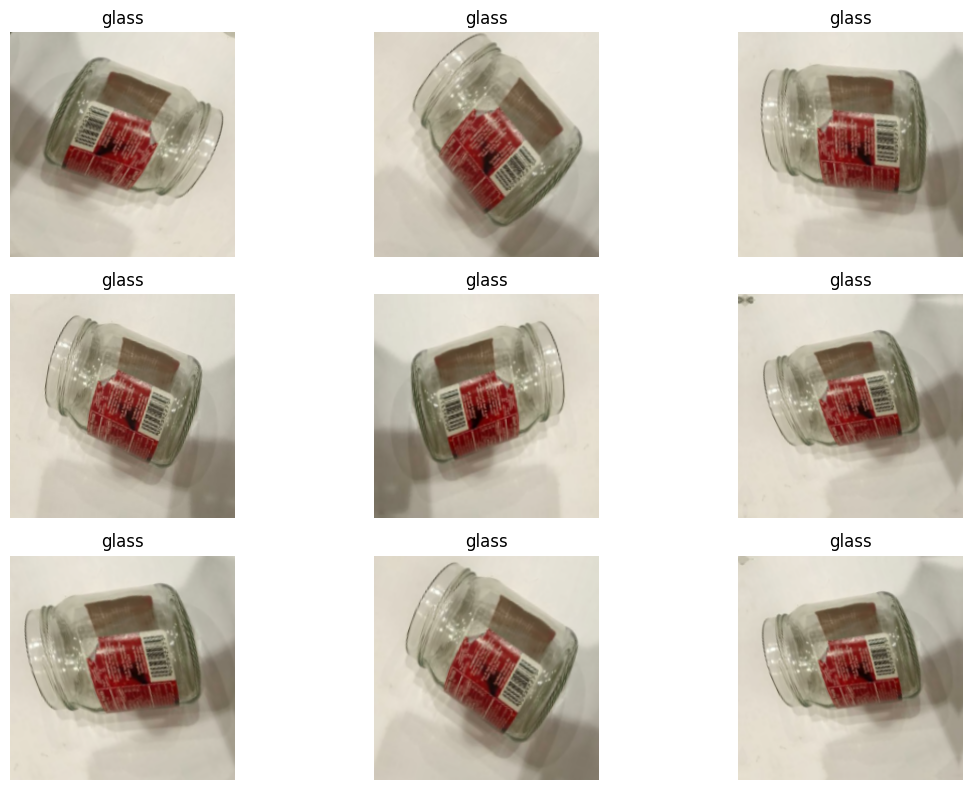

In [48]:
# ==========================================
# STEP 41 — VISUALIZE STANDARD AUGMENTATION
# ==========================================

plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):

    sample_image = images[0]

    for i in range(9):

        augmented_image = standard_augmentation(
            tf.expand_dims(sample_image, 0),
            training=True
        )

        augmented_image = (
            augmented_image[0].numpy()
        )

        augmented_image = np.clip(
            augmented_image,
            0,
            255
        ).astype("uint8")

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            augmented_image
        )

        plt.title(
            class_names[
                labels[0].numpy()
            ]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [49]:
# ==========================================
# STEP 42 — BUILD STANDARD AUGMENTATION CNN
# ==========================================

augmented_model = models.Sequential([

    layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    # Standard augmentation
    standard_augmentation,

    # Normalize
    layers.Rescaling(
        1.0 / 255
    ),

    # CNN Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # CNN Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # CNN Block 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Classification
    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

print("Augmented CNN created!")

Augmented CNN created!


In [50]:
# ==========================================
# STEP 43 — COMPILE AUGMENTED CNN
# ==========================================

augmented_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        "accuracy"
    ]
)

print("Augmented CNN compiled!")

Augmented CNN compiled!


In [51]:
# ==========================================
# STEP 44 — TRAIN STANDARD AUGMENTATION CNN
# ==========================================

history_augmented = augmented_model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=20
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.3188 - loss: 1.8536 - val_accuracy: 0.4005 - val_loss: 1.4061
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.4581 - loss: 1.3703 - val_accuracy: 0.4324 - val_loss: 1.4015
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.4915 - loss: 1.2988 - val_accuracy: 0.5040 - val_loss: 1.2419
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.5589 - loss: 1.1498 - val_accuracy: 0.4907 - val_loss: 1.2104
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.6093 - loss: 1.0413 - val_accuracy: 0.5623 - val_loss: 1.1090
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.6048 - loss: 1.0274 - val_accuracy: 0.5782 - val_loss: 1.1241
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.6359 - loss: 0.9760 - val_accuracy: 0.5862 - val_loss: 1.0043
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.6755 - loss: 0.9071 - val_accuracy: 0.6180 - v

In [52]:
# ==========================================
# STEP 45 — EVALUATE STANDARD AUGMENTATION
# ==========================================

aug_test_loss, aug_test_accuracy = (
    augmented_model.evaluate(
        test_dataset
    )
)

print("\n================================")
print("STANDARD AUGMENTATION RESULTS")
print("================================")

print(
    "Test Loss     :",
    aug_test_loss
)

print(
    "Test Accuracy :",
    aug_test_accuracy
)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7083 - loss: 0.8895

STANDARD AUGMENTATION RESULTS
Test Loss     : 0.889453113079071
Test Accuracy : 0.7083333134651184


In [53]:
# ==========================================
# STEP 46 — AUGMENTED MODEL PREDICTIONS
# ==========================================

y_true_aug = []
y_pred_aug = []

for images, labels in test_dataset:

    predictions = augmented_model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true_aug.extend(
        labels.numpy()
    )

    y_pred_aug.extend(
        predicted_classes
    )

y_true_aug = np.array(y_true_aug)
y_pred_aug = np.array(y_pred_aug)

print("Augmented model predictions generated!")

Augmented model predictions generated!


In [54]:
# ==========================================
# STEP 47 — AUGMENTED CLASSIFICATION REPORT
# ==========================================

print(
    classification_report(
        y_true_aug,
        y_pred_aug,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

   cardboard     0.7826    0.8852    0.8308        61
       glass     0.5960    0.7763    0.6743        76
       metal     0.6981    0.5968    0.6435        62
       paper     0.8046    0.7778    0.7910        90
     plastic     0.8684    0.4521    0.5946        73
       trash     0.5000    0.8636    0.6333        22

    accuracy                         0.7083       384
   macro avg     0.7083    0.7253    0.6946       384
weighted avg     0.7373    0.7083    0.7040       384



In [55]:
# ==========================================
# STEP 48 — STORE AUGMENTATION METRICS
# ==========================================

aug_accuracy = accuracy_score(
    y_true_aug,
    y_pred_aug
)

aug_precision = precision_score(
    y_true_aug,
    y_pred_aug,
    average="weighted",
    zero_division=0
)

aug_recall = recall_score(
    y_true_aug,
    y_pred_aug,
    average="weighted",
    zero_division=0
)

aug_f1 = f1_score(
    y_true_aug,
    y_pred_aug,
    average="weighted",
    zero_division=0
)

print("Augmentation Accuracy :", aug_accuracy)
print("Augmentation Precision:", aug_precision)
print("Augmentation Recall   :", aug_recall)
print("Augmentation F1       :", aug_f1)

Augmentation Accuracy : 0.7083333333333334
Augmentation Precision: 0.7373010639093488
Augmentation Recall   : 0.7083333333333334
Augmentation F1       : 0.7040194503991023


In [56]:
# ==========================================
# STEP 49 — IMAGE DIFFICULTY ANALYSIS
# ==========================================

difficulty_records = []

image_counter = 0

for images, labels in train_dataset:

    predictions = baseline_model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    confidence_scores = np.max(
        predictions,
        axis=1
    )

    for i in range(len(labels)):

        actual_class = int(
            labels[i].numpy()
        )

        predicted_class = int(
            predicted_classes[i]
        )

        confidence = float(
            confidence_scores[i]
        )

        # Basic difficulty score
        difficulty = 1.0 - confidence

        # Add extra penalty for incorrect predictions
        if actual_class != predicted_class:
            difficulty = min(
                1.0,
                difficulty + 0.25
            )

        difficulty_records.append({

            "image_index": image_counter,

            "actual_class": actual_class,

            "predicted_class": predicted_class,

            "confidence": confidence,

            "difficulty": difficulty
        })

        image_counter += 1

print(
    "Difficulty scores generated for",
    len(difficulty_records),
    "training images."
)

Difficulty scores generated for 1766 training images.


In [57]:
# ==========================================
# STEP 50 — DIFFICULTY DATAFRAME
# ==========================================

import pandas as pd

difficulty_df = pd.DataFrame(
    difficulty_records
)

difficulty_df["actual_name"] = (
    difficulty_df["actual_class"]
    .apply(
        lambda x: class_names[x]
    )
)

difficulty_df["predicted_name"] = (
    difficulty_df["predicted_class"]
    .apply(
        lambda x: class_names[x]
    )
)

print(
    difficulty_df.head(10)
)

   image_index  actual_class  predicted_class  confidence  difficulty  \
0            0             3                3    0.999986    0.000014   
1            1             0                0    0.999790    0.000210   
2            2             3                3    1.000000    0.000000   
3            3             2                2    1.000000    0.000000   
4            4             2                2    0.999778    0.000222   
5            5             4                4    0.956193    0.043807   
6            6             4                4    1.000000    0.000000   
7            7             3                3    1.000000    0.000000   
8            8             4                4    1.000000    0.000000   
9            9             1                1    1.000000    0.000000   

  actual_name predicted_name  
0       paper          paper  
1   cardboard      cardboard  
2       paper          paper  
3       metal          metal  
4       metal          metal  
5     plas

In [58]:
# ==========================================
# STEP 51 — DIFFICULTY STATISTICS
# ==========================================

print(
    difficulty_df["difficulty"].describe()
)

count    1.766000e+03
mean     1.840727e-02
std      6.597087e-02
min      0.000000e+00
25%      1.192093e-07
50%      7.128716e-05
75%      3.552645e-03
max      6.925843e-01
Name: difficulty, dtype: float64


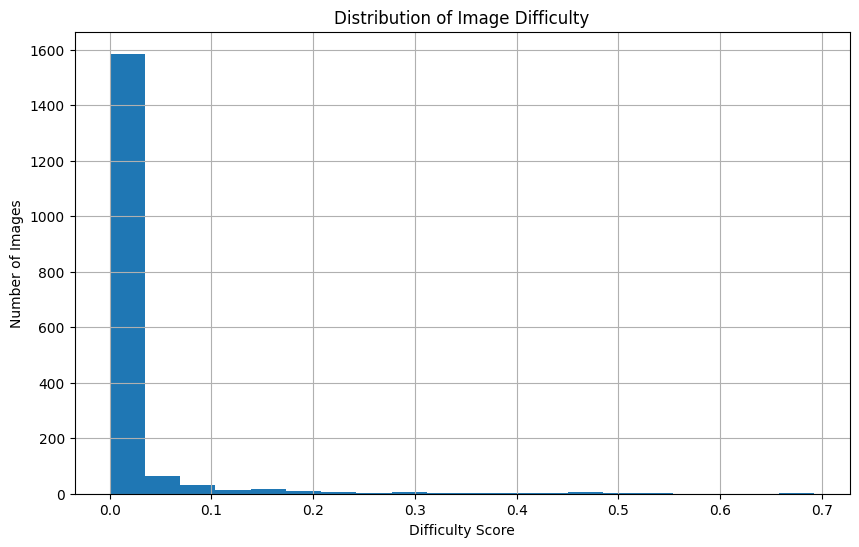

In [59]:
# ==========================================
# STEP 52 — DIFFICULTY DISTRIBUTION
# ==========================================

plt.figure(figsize=(10, 6))

plt.hist(
    difficulty_df["difficulty"],
    bins=20
)

plt.xlabel("Difficulty Score")
plt.ylabel("Number of Images")

plt.title(
    "Distribution of Image Difficulty"
)

plt.grid(True)

plt.show()

In [60]:
# ==========================================
# STEP 53 — DIFFICULTY CATEGORIES
# ==========================================

def difficulty_category(score):

    if score < 0.30:
        return "Easy"

    elif score < 0.60:
        return "Medium"

    else:
        return "Hard"


difficulty_df["difficulty_level"] = (
    difficulty_df["difficulty"]
    .apply(difficulty_category)
)

print(
    difficulty_df[
        "difficulty_level"
    ].value_counts()
)

difficulty_level
Easy      1736
Medium      27
Hard         3
Name: count, dtype: int64


In [61]:
# ==========================================
# STEP 54 — CLASS-WISE DIFFICULTY
# ==========================================

class_difficulty = (
    difficulty_df
    .groupby("actual_name")["difficulty"]
    .mean()
    .sort_values(
        ascending=False
    )
)

print(class_difficulty)

actual_name
glass        0.043629
plastic      0.022050
trash        0.021155
metal        0.017064
cardboard    0.004250
paper        0.004098
Name: difficulty, dtype: float64


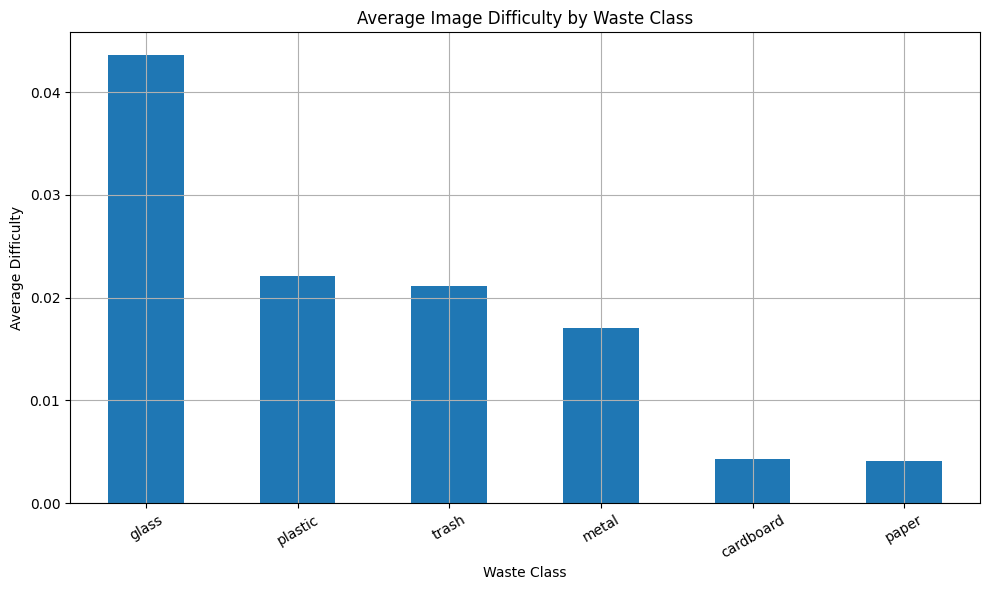

In [62]:
# ==========================================
# STEP 55 — CLASS DIFFICULTY GRAPH
# ==========================================

plt.figure(figsize=(10, 6))

class_difficulty.plot(
    kind="bar"
)

plt.xlabel("Waste Class")
plt.ylabel("Average Difficulty")

plt.title(
    "Average Image Difficulty by Waste Class"
)

plt.xticks(
    rotation=30
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [63]:
# ==========================================
# STEP 56 — DIFFICULTY-GUIDED AUGMENTATION
# ==========================================

def augment_easy(image):

    image = tf.image.random_flip_left_right(
        image
    )

    return image


def augment_medium(image):

    image = tf.image.random_flip_left_right(
        image
    )

    image = tf.image.random_brightness(
        image,
        max_delta=0.10
    )

    return image


def augment_hard(image):

    image = tf.image.random_flip_left_right(
        image
    )

    image = tf.image.random_brightness(
        image,
        max_delta=0.20
    )

    image = tf.image.random_contrast(
        image,
        lower=0.75,
        upper=1.25
    )

    return image


print("Difficulty-guided augmentation functions created!")

Difficulty-guided augmentation functions created!


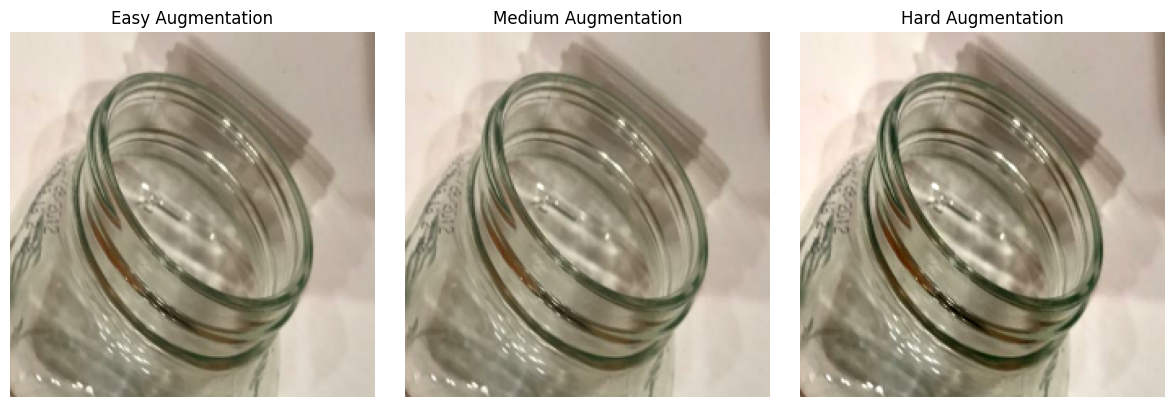

In [64]:
# ==========================================
# STEP 57 — TEST ADAPTIVE AUGMENTATION
# ==========================================

for images, labels in train_dataset.take(1):

    sample = images[0]

    easy_image = augment_easy(sample)

    medium_image = augment_medium(sample)

    hard_image = augment_hard(sample)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(
        tf.cast(
            tf.clip_by_value(
                easy_image,
                0,
                255
            ),
            tf.uint8
        )
    )
    plt.title("Easy Augmentation")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(
        tf.cast(
            tf.clip_by_value(
                medium_image,
                0,
                255
            ),
            tf.uint8
        )
    )
    plt.title("Medium Augmentation")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(
        tf.cast(
            tf.clip_by_value(
                hard_image,
                0,
                255
            ),
            tf.uint8
        )
    )
    plt.title("Hard Augmentation")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    break

In [65]:
# ==========================================
# STEP 58 — PREPARE DIFFICULTY THRESHOLDS
# ==========================================

EASY_THRESHOLD = 0.30
HARD_THRESHOLD = 0.60

print("Easy threshold  :", EASY_THRESHOLD)
print("Hard threshold  :", HARD_THRESHOLD)

Easy threshold  : 0.3
Hard threshold  : 0.6


In [66]:
# ==========================================
# STEP 59 — CREATE ADAPTIVE DATASET
# ==========================================

adaptive_images = []
adaptive_labels = []

# Convert training images into arrays
for images, labels in train_dataset:

    for i in range(len(images)):

        adaptive_images.append(
            images[i].numpy()
        )

        adaptive_labels.append(
            labels[i].numpy()
        )

adaptive_images = np.array(
    adaptive_images
)

adaptive_labels = np.array(
    adaptive_labels
)

print(
    "Images loaded:",
    adaptive_images.shape
)

print(
    "Labels loaded:",
    adaptive_labels.shape
)

Images loaded: (1766, 224, 224, 3)
Labels loaded: (1766,)


In [67]:
# ==========================================
# STEP 60 — MATCH DIFFICULTY SCORES
# ==========================================

difficulty_scores = (
    difficulty_df["difficulty"]
    .values
)

print(
    "Number of images:",
    len(adaptive_images)
)

print(
    "Number of difficulty scores:",
    len(difficulty_scores)
)

Number of images: 1766
Number of difficulty scores: 1766


In [68]:
# ==========================================
# STEP 61 — GENERATE ADAPTIVE DATA
# ==========================================

adaptive_augmented_images = []
adaptive_augmented_labels = []

for i in range(
    len(adaptive_images)
):

    image = tf.convert_to_tensor(
        adaptive_images[i],
        dtype=tf.float32
    )

    label = adaptive_labels[i]

    difficulty = difficulty_scores[i]

    # --------------------------------------
    # EASY
    # --------------------------------------
    if difficulty < EASY_THRESHOLD:

        augmented = augment_easy(
            image
        )

    # --------------------------------------
    # MEDIUM
    # --------------------------------------
    elif difficulty < HARD_THRESHOLD:

        augmented = augment_medium(
            image
        )

    # --------------------------------------
    # HARD
    # --------------------------------------
    else:

        augmented = augment_hard(
            image
        )

    adaptive_augmented_images.append(
        augmented.numpy()
    )

    adaptive_augmented_labels.append(
        label
    )


adaptive_augmented_images = np.array(
    adaptive_augmented_images
)

adaptive_augmented_labels = np.array(
    adaptive_augmented_labels
)

print(
    "Adaptive augmented dataset:",
    adaptive_augmented_images.shape
)

Adaptive augmented dataset: (1766, 224, 224, 3)


In [69]:
# ==========================================
# STEP 62 — COMBINE ORIGINAL AND ADAPTIVE DATA
# ==========================================

final_train_images = np.concatenate(
    [
        adaptive_images,
        adaptive_augmented_images
    ],
    axis=0
)

final_train_labels = np.concatenate(
    [
        adaptive_labels,
        adaptive_augmented_labels
    ],
    axis=0
)

print(
    "Final adaptive training images:",
    final_train_images.shape
)

print(
    "Final adaptive training labels:",
    final_train_labels.shape
)

Final adaptive training images: (3532, 224, 224, 3)
Final adaptive training labels: (3532,)


In [70]:
# ==========================================
# STEP 63 — SHUFFLE ADAPTIVE DATASET
# ==========================================

shuffle_indices = np.random.permutation(
    len(final_train_images)
)

final_train_images = (
    final_train_images[
        shuffle_indices
    ]
)

final_train_labels = (
    final_train_labels[
        shuffle_indices
    ]
)

print("Adaptive dataset shuffled!")

Adaptive dataset shuffled!


In [71]:
# ==========================================
# STEP 64 — CREATE ADAPTIVE TF DATASET
# ==========================================

adaptive_train_dataset = (
    tf.data.Dataset.from_tensor_slices(
        (
            final_train_images,
            final_train_labels
        )
    )
)

adaptive_train_dataset = (
    adaptive_train_dataset
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(
        tf.data.AUTOTUNE
    )
)

print(
    "Adaptive TensorFlow dataset created!"
)

Adaptive TensorFlow dataset created!


In [72]:
# ==========================================
# STEP 65 — BUILD ADAPTIVE CNN
# ==========================================

adaptive_model = models.Sequential([

    layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    layers.Rescaling(
        1.0 / 255
    ),

    # Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Block 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Classification
    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

print("Adaptive CNN created!")

Adaptive CNN created!


In [73]:
# ==========================================
# STEP 66 — COMPILE ADAPTIVE CNN
# ==========================================

adaptive_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        "accuracy"
    ]
)

print("Adaptive CNN compiled!")

Adaptive CNN compiled!


In [74]:
# ==========================================
# STEP 67 — TRAIN ADAPTIVE CNN
# ==========================================

history_adaptive = adaptive_model.fit(

    adaptive_train_dataset,

    validation_data=validation_dataset,

    epochs=20
)

Epoch 1/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - accuracy: 0.3853 - loss: 1.6441 - val_accuracy: 0.4615 - val_loss: 1.3778
Epoch 2/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.5702 - loss: 1.1420 - val_accuracy: 0.5464 - val_loss: 1.1950
Epoch 3/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.6939 - loss: 0.8350 - val_accuracy: 0.6127 - val_loss: 1.0315
Epoch 4/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.7800 - loss: 0.6098 - val_accuracy: 0.6525 - val_loss: 1.1202
Epoch 5/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.8681 - loss: 0.3682 - val_accuracy: 0.6154 - val_loss: 1.4875
Epoch 6/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.9272 - loss: 0.2045 - val_accuracy: 0.6180 - val_loss: 1.7801
Epoch 7/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.9530 - loss: 0.1446 - val_accuracy: 0.5889 - val_loss: 1.8832
Epoch 8/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.9711 - loss: 0.0992 - val_acc

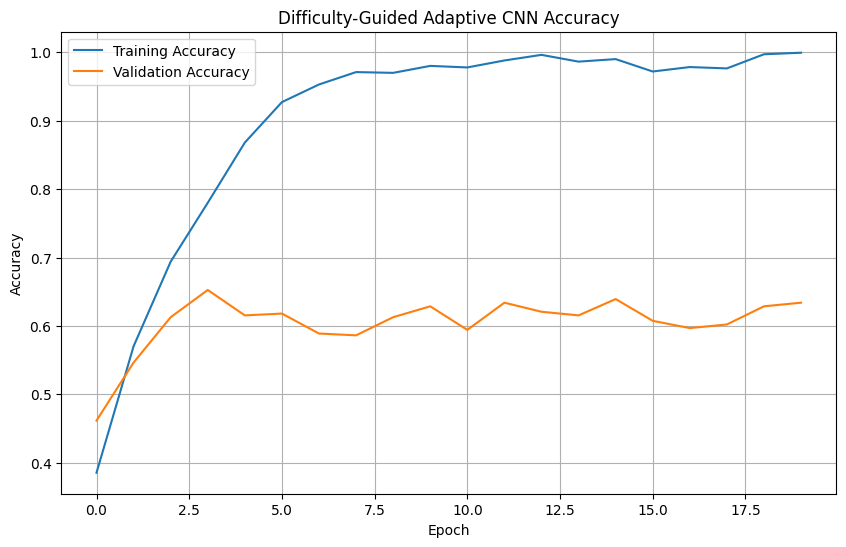

In [75]:
# ==========================================
# STEP 68 — ADAPTIVE ACCURACY
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_adaptive.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_adaptive.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Difficulty-Guided Adaptive CNN Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

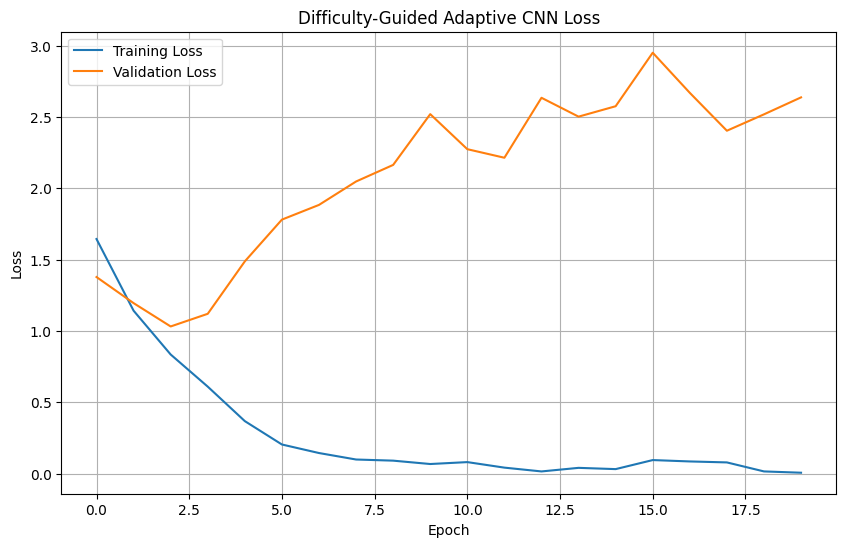

In [76]:
# ==========================================
# STEP 69 — ADAPTIVE LOSS
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_adaptive.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_adaptive.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Difficulty-Guided Adaptive CNN Loss"
)

plt.legend()
plt.grid(True)

plt.show()

In [77]:
# ==========================================
# STEP 70 — FINAL TEST EVALUATION
# ==========================================

adaptive_test_loss, adaptive_test_accuracy = (
    adaptive_model.evaluate(
        test_dataset
    )
)

print("\n================================")
print("ADAPTIVE CNN RESULTS")
print("================================")

print(
    "Test Loss     :",
    adaptive_test_loss
)

print(
    "Test Accuracy :",
    adaptive_test_accuracy
)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6172 - loss: 2.7720

ADAPTIVE CNN RESULTS
Test Loss     : 2.771993637084961
Test Accuracy : 0.6171875


In [78]:
# ==========================================
# STEP 71 — ADAPTIVE PREDICTIONS
# ==========================================

y_true_adaptive = []
y_pred_adaptive = []

for images, labels in test_dataset:

    predictions = adaptive_model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true_adaptive.extend(
        labels.numpy()
    )

    y_pred_adaptive.extend(
        predicted_classes
    )

y_true_adaptive = np.array(
    y_true_adaptive
)

y_pred_adaptive = np.array(
    y_pred_adaptive
)

print("Adaptive predictions generated!")

Adaptive predictions generated!


In [79]:
# ==========================================
# STEP 72 — ADAPTIVE CLASSIFICATION REPORT
# ==========================================

print(
    classification_report(
        y_true_adaptive,
        y_pred_adaptive,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

   cardboard     0.7101    0.8033    0.7538        61
       glass     0.5333    0.6316    0.5783        76
       metal     0.5238    0.5323    0.5280        62
       paper     0.6914    0.6222    0.6550        90
     plastic     0.6406    0.5616    0.5985        73
       trash     0.5882    0.4545    0.5128        22

    accuracy                         0.6172       384
   macro avg     0.6146    0.6009    0.6044       384
weighted avg     0.6205    0.6172    0.6161       384



In [80]:
# ==========================================
# STEP 73 — ADAPTIVE METRICS
# ==========================================

adaptive_accuracy = accuracy_score(
    y_true_adaptive,
    y_pred_adaptive
)

adaptive_precision = precision_score(
    y_true_adaptive,
    y_pred_adaptive,
    average="weighted",
    zero_division=0
)

adaptive_recall = recall_score(
    y_true_adaptive,
    y_pred_adaptive,
    average="weighted",
    zero_division=0
)

adaptive_f1 = f1_score(
    y_true_adaptive,
    y_pred_adaptive,
    average="weighted",
    zero_division=0
)

print("Adaptive Accuracy :", adaptive_accuracy)
print("Adaptive Precision:", adaptive_precision)
print("Adaptive Recall   :", adaptive_recall)
print("Adaptive F1       :", adaptive_f1)

Adaptive Accuracy : 0.6171875
Adaptive Precision: 0.6204619481303241
Adaptive Recall   : 0.6171875
Adaptive F1       : 0.6161335233686699


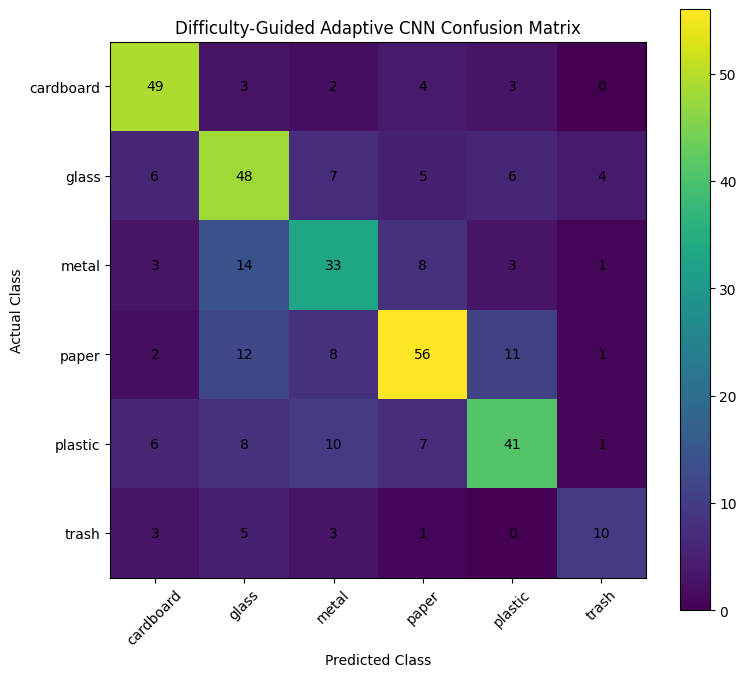

In [81]:
# ==========================================
# STEP 74 — ADAPTIVE CONFUSION MATRIX
# ==========================================

cm_adaptive = confusion_matrix(
    y_true_adaptive,
    y_pred_adaptive
)

plt.figure(figsize=(8, 7))

plt.imshow(cm_adaptive)

plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=45
)

plt.yticks(
    range(NUM_CLASSES),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Difficulty-Guided Adaptive CNN Confusion Matrix"
)

for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        plt.text(
            j,
            i,
            cm_adaptive[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [82]:
# ==========================================
# STEP 75 — SAVE ADAPTIVE MODEL
# ==========================================

adaptive_model.save(
    "/content/waste_project/adaptive_cnn.keras"
)

print("Adaptive CNN saved successfully!")

Adaptive CNN saved successfully!


In [83]:
# ==========================================
# STEP 76 — FINAL RESULTS TABLE
# ==========================================

results = pd.DataFrame({

    "Model": [
        "Baseline CNN",
        "CNN + Standard Augmentation",
        "Difficulty-Guided Adaptive CNN"
    ],

    "Accuracy": [
        baseline_accuracy,
        aug_accuracy,
        adaptive_accuracy
    ],

    "Precision": [
        baseline_precision,
        aug_precision,
        adaptive_precision
    ],

    "Recall": [
        baseline_recall,
        aug_recall,
        adaptive_recall
    ],

    "F1 Score": [
        baseline_f1,
        aug_f1,
        adaptive_f1
    ]
})

print(results)

                            Model  Accuracy  Precision    Recall  F1 Score
0                    Baseline CNN  0.549479   0.552118  0.549479  0.542532
1     CNN + Standard Augmentation  0.708333   0.737301  0.708333  0.704019
2  Difficulty-Guided Adaptive CNN  0.617188   0.620462  0.617188  0.616134


In [84]:
# ==========================================
# STEP 77 — FORMAT RESULTS
# ==========================================

results_display = results.copy()

for column in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]:

    results_display[column] = (
        results_display[column] * 100
    ).round(2)

print(
    results_display.to_string(
        index=False
    )
)

                         Model  Accuracy  Precision  Recall  F1 Score
                  Baseline CNN     54.95      55.21   54.95     54.25
   CNN + Standard Augmentation     70.83      73.73   70.83     70.40
Difficulty-Guided Adaptive CNN     61.72      62.05   61.72     61.61


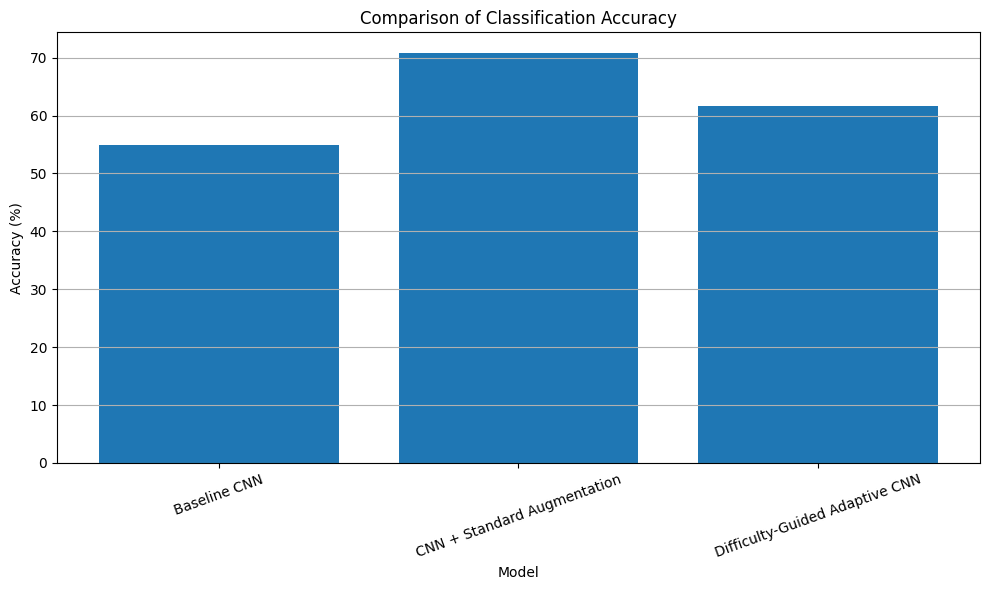

In [85]:
# ==========================================
# STEP 78 — ACCURACY COMPARISON
# ==========================================

plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["Accuracy"] * 100
)

plt.ylabel("Accuracy (%)")

plt.xlabel("Model")

plt.title(
    "Comparison of Classification Accuracy"
)

plt.xticks(
    rotation=20
)

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.show()

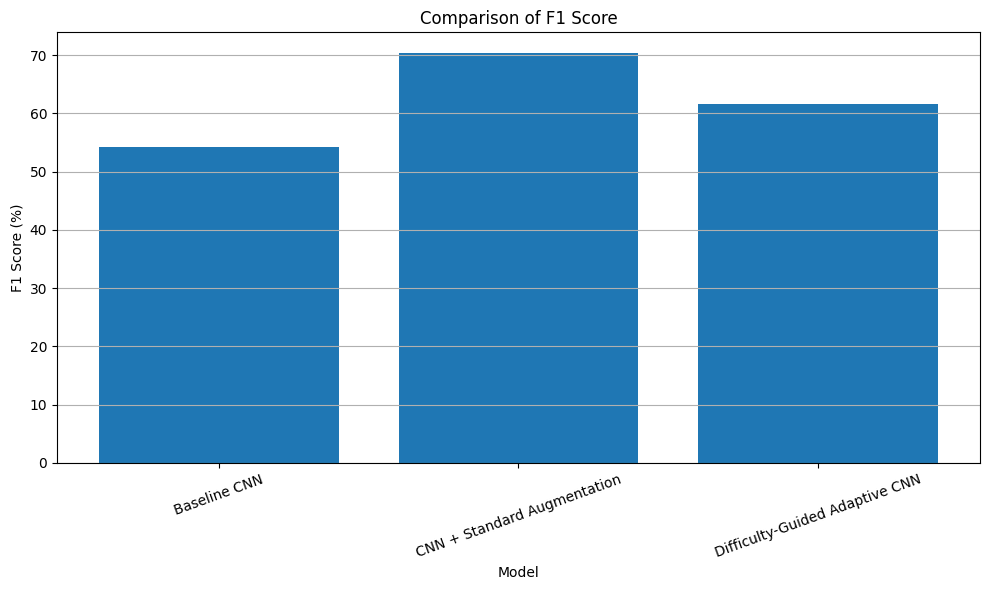

In [86]:
# ==========================================
# STEP 79 — F1 SCORE COMPARISON
# ==========================================

plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["F1 Score"] * 100
)

plt.ylabel("F1 Score (%)")

plt.xlabel("Model")

plt.title(
    "Comparison of F1 Score"
)

plt.xticks(
    rotation=20
)

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.show()

In [87]:
# ==========================================
# STEP 80 — IMPROVEMENT ANALYSIS
# ==========================================

accuracy_improvement = (
    adaptive_accuracy
    - baseline_accuracy
)

f1_improvement = (
    adaptive_f1
    - baseline_f1
)

print(
    "Adaptive Accuracy Improvement:",
    round(
        accuracy_improvement * 100,
        2
    ),
    "percentage points"
)

print(
    "Adaptive F1 Improvement:",
    round(
        f1_improvement * 100,
        2
    ),
    "percentage points"
)

Adaptive Accuracy Improvement: 6.77 percentage points
Adaptive F1 Improvement: 7.36 percentage points


In [88]:
# ==========================================
# STEP 81 — SAVE RESULTS
# ==========================================

results.to_csv(
    "/content/waste_project/model_comparison.csv",
    index=False
)

difficulty_df.to_csv(
    "/content/waste_project/image_difficulty.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [89]:
# ==========================================
# STEP 82 — FINAL SUMMARY
# ==========================================

print("=" * 60)
print("        WASTE CLASSIFICATION PROJECT")
print("=" * 60)

print("\nDataset:")
print("TrashNet")
print("Classes:", ", ".join(class_names))

print("\nModels:")
print("1. Baseline CNN")
print("2. CNN + Standard Augmentation")
print("3. Difficulty-Guided Adaptive CNN")

print("\nPerformance:")
print(
    results_display.to_string(
        index=False
    )
)

print("\nAdaptive Improvement:")
print(
    round(
        accuracy_improvement * 100,
        2
    ),
    "percentage points in accuracy"
)

print(
    round(
        f1_improvement * 100,
        2
    ),
    "percentage points in F1 score"
)

print("\nProject implementation completed!")

        WASTE CLASSIFICATION PROJECT

Dataset:
TrashNet
Classes: cardboard, glass, metal, paper, plastic, trash

Models:
1. Baseline CNN
2. CNN + Standard Augmentation
3. Difficulty-Guided Adaptive CNN

Performance:
                         Model  Accuracy  Precision  Recall  F1 Score
                  Baseline CNN     54.95      55.21   54.95     54.25
   CNN + Standard Augmentation     70.83      73.73   70.83     70.40
Difficulty-Guided Adaptive CNN     61.72      62.05   61.72     61.61

Adaptive Improvement:
6.77 percentage points in accuracy
7.36 percentage points in F1 score

Project implementation completed!


Testing


In [90]:
print("========== DATASET VALIDATION ==========")

train_count = 0
val_count = 0
test_count = 0

for images, labels in train_dataset:
    train_count += images.shape[0]

for images, labels in validation_dataset:
    val_count += images.shape[0]

for images, labels in test_dataset:
    test_count += images.shape[0]

print("Training images   :", train_count)
print("Validation images :", val_count)
print("Test images       :", test_count)
print("Total images      :", train_count + val_count + test_count)

========== DATASET VALIDATION ==========
Training images   : 1766
Validation images : 377
Test images       : 384
Total images      : 2527


In [91]:
from collections import Counter

def get_class_distribution(dataset):
    labels = []

    for _, batch_labels in dataset:
        labels.extend(batch_labels.numpy())

    return Counter(labels)


train_distribution = get_class_distribution(train_dataset)
val_distribution = get_class_distribution(validation_dataset)
test_distribution = get_class_distribution(test_dataset)

print("========== TRAIN DISTRIBUTION ==========")

for class_id, count in sorted(train_distribution.items()):
    print(f"{class_names[class_id]:12s}: {count}")

print("\n========== VALIDATION DISTRIBUTION ==========")

for class_id, count in sorted(val_distribution.items()):
    print(f"{class_names[class_id]:12s}: {count}")

print("\n========== TEST DISTRIBUTION ==========")

for class_id, count in sorted(test_distribution.items()):
    print(f"{class_names[class_id]:12s}: {count}")

========== TRAIN DISTRIBUTION ==========
cardboard   : 282
glass       : 350
metal       : 287
paper       : 415
plastic     : 337
trash       : 95

========== VALIDATION DISTRIBUTION ==========
cardboard   : 60
glass       : 75
metal       : 61
paper       : 89
plastic     : 72
trash       : 20

========== TEST DISTRIBUTION ==========
cardboard   : 61
glass       : 76
metal       : 62
paper       : 90
plastic     : 73
trash       : 22


In [92]:
print("========== DIFFICULTY VALIDATION ==========")

print("Number of training images :", train_count)
print("Number of difficulty scores:", len(difficulty_scores))

========== DIFFICULTY VALIDATION ==========
Number of training images : 1766
Number of difficulty scores: 1766


In [93]:
import numpy as np

# Define difficulty thresholds
EASY_THRESHOLD = 0.30
MEDIUM_THRESHOLD = 0.60

difficulty_categories = []

for score in difficulty_scores:
    if score < EASY_THRESHOLD:
        difficulty_categories.append("Easy")
    elif score < MEDIUM_THRESHOLD:
        difficulty_categories.append("Medium")
    else:
        difficulty_categories.append("Hard")

print("Difficulty categories created successfully!")
print("Total categories:", len(difficulty_categories))

Difficulty categories created successfully!
Total categories: 1766


In [94]:
from collections import Counter

difficulty_distribution = Counter(difficulty_categories)

print("========== DIFFICULTY DISTRIBUTION ==========")

for category in ["Easy", "Medium", "Hard"]:
    print(f"{category:10s}: {difficulty_distribution.get(category, 0)}")

print("\nTotal:", sum(difficulty_distribution.values()))
print("Difficulty scores:", len(difficulty_scores))

========== DIFFICULTY DISTRIBUTION ==========
Easy      : 1736
Medium    : 27
Hard      : 3

Total: 1766
Difficulty scores: 1766


In [95]:
import numpy as np

scores = np.array(difficulty_scores)

print("========== DIFFICULTY SCORE ANALYSIS ==========")

print("Minimum :", scores.min())
print("Maximum :", scores.max())
print("Mean    :", scores.mean())
print("Median  :", np.median(scores))
print("Std Dev :", scores.std())

print("\nPercentiles:")
print("25th percentile :", np.percentile(scores, 25))
print("50th percentile :", np.percentile(scores, 50))
print("75th percentile :", np.percentile(scores, 75))
print("90th percentile :", np.percentile(scores, 90))
print("95th percentile :", np.percentile(scores, 95))
print("99th percentile :", np.percentile(scores, 99))

========== DIFFICULTY SCORE ANALYSIS ==========
Minimum : 0.0
Maximum : 0.6925842761993408
Mean    : 0.01840726624528792
Median  : 7.128715515136719e-05
Std Dev : 0.06595219281376062

Percentiles:
25th percentile : 1.1920928955078125e-07
50th percentile : 7.128715515136719e-05
75th percentile : 0.003552645444869995
90th percentile : 0.036186784505844116
95th percentile : 0.10131523013114929
99th percentile : 0.3862798362970349


In [96]:
print("========== TRAIN DATASET CHECK ==========")

print("Has file_paths:", hasattr(train_dataset, "file_paths"))

if hasattr(train_dataset, "file_paths"):
    print("Number of file paths:", len(train_dataset.file_paths))

    print("\nFirst 5 training image paths:")
    for path in train_dataset.file_paths[:5]:
        print(path)

========== TRAIN DATASET CHECK ==========
Has file_paths: False


In [97]:
print("\n========== DATASET OBJECT ==========")
print(train_dataset)


========== DATASET OBJECT ==========
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [98]:
print("========== BASELINE PREDICTION CHECK ==========")

incorrect_count = np.sum(y_true != y_pred)
correct_count = np.sum(y_true == y_pred)

print("Correct predictions  :", correct_count)
print("Incorrect predictions:", incorrect_count)
print("Total predictions    :", len(y_true))

print("\nAccuracy calculated from predictions:",
      correct_count / len(y_true))

========== BASELINE PREDICTION CHECK ==========
Correct predictions  : 211
Incorrect predictions: 173
Total predictions    : 384

Accuracy calculated from predictions: 0.5494791666666666


In [99]:
print("========== DATASET VARIABLES ==========")

variable_names = list(globals().keys())

for name in variable_names:
    if any(word in name.lower() for word in ["dataset", "dir", "path"]):
        try:
            value = globals()[name]
            print(f"{name} -> {type(value).__name__}")
        except Exception:
            pass

========== DATASET VARIABLES ==========
directories -> list
directory -> str
dirs -> list
zip_path -> str
extract_path -> str
dataset_path -> str
image_path -> str
train_dir -> str
val_dir -> str
test_dir -> str
train_dataset -> _PrefetchDataset
validation_dataset -> _PrefetchDataset
test_dataset -> _PrefetchDataset
adaptive_train_dataset -> _PrefetchDataset


In [100]:
print("========== DATASET CREATION VARIABLES ==========")

variable_names = list(globals().keys())

for name in variable_names:
    if any(word in name.lower() for word in ["dir", "path"]):
        try:
            value = globals()[name]

            if isinstance(value, str):
                print(f"{name} = {value}")
        except Exception:
            pass

========== DATASET CREATION VARIABLES ==========
directory = /content/waste_project/results/metrics
zip_path = /content/trashnet.zip
extract_path = /content/waste_project/dataset
dataset_path = /content/waste_project/dataset/dataset-resized
image_path = /content/waste_project/dataset/dataset-resized/trash/trash78.jpg
train_dir = /content/waste_project/split_dataset/train
val_dir = /content/waste_project/split_dataset/validation
test_dir = /content/waste_project/split_dataset/test


In [101]:
import tensorflow as tf

print("========== CREATING DETERMINISTIC TRAIN DATASET ==========")

train_analysis_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nDeterministic training dataset created!")
print("Number of images:", len(train_analysis_dataset.file_paths))

print("\nFirst 5 files:")
for path in train_analysis_dataset.file_paths[:5]:
    print(path)

========== CREATING DETERMINISTIC TRAIN DATASET ==========
Found 1766 files belonging to 6 classes.

Deterministic training dataset created!
Number of images: 1766

First 5 files:
/content/waste_project/split_dataset/train/cardboard/cardboard1.jpg
/content/waste_project/split_dataset/train/cardboard/cardboard103.jpg
/content/waste_project/split_dataset/train/cardboard/cardboard105.jpg
/content/waste_project/split_dataset/train/cardboard/cardboard106.jpg
/content/waste_project/split_dataset/train/cardboard/cardboard107.jpg


In [102]:
import numpy as np

print("========== RECOMPUTING DIFFICULTY SCORES ==========")

corrected_difficulty_scores = []
corrected_predictions = []
corrected_true_labels = []

for images, labels in train_analysis_dataset:

    predictions = baseline_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)
    confidence = np.max(predictions, axis=1)

    # Difficulty based on prediction confidence
    difficulty = 1.0 - confidence

    # Add penalty for incorrect predictions
    incorrect_mask = predicted_classes != labels.numpy()
    difficulty[incorrect_mask] += 0.25

    # Keep difficulty between 0 and 1
    difficulty = np.clip(difficulty, 0, 1)

    corrected_difficulty_scores.extend(difficulty)
    corrected_predictions.extend(predicted_classes)
    corrected_true_labels.extend(labels.numpy())

corrected_difficulty_scores = np.array(corrected_difficulty_scores)
corrected_predictions = np.array(corrected_predictions)
corrected_true_labels = np.array(corrected_true_labels)

print("Difficulty calculation completed!")

print("Number of images :", len(corrected_difficulty_scores))
print("Number of labels :", len(corrected_true_labels))
print("Number of predictions :", len(corrected_predictions))

========== RECOMPUTING DIFFICULTY SCORES ==========
Difficulty calculation completed!
Number of images : 1766
Number of labels : 1766
Number of predictions : 1766


In [103]:
print("========== CORRECTED DIFFICULTY STATISTICS ==========")

scores = corrected_difficulty_scores

print("Minimum :", scores.min())
print("Maximum :", scores.max())
print("Mean    :", scores.mean())
print("Median  :", np.median(scores))

print("\nPercentiles:")
print("25th percentile :", np.percentile(scores, 25))
print("50th percentile :", np.percentile(scores, 50))
print("75th percentile :", np.percentile(scores, 75))
print("90th percentile :", np.percentile(scores, 90))
print("95th percentile :", np.percentile(scores, 95))
print("99th percentile :", np.percentile(scores, 99))

========== CORRECTED DIFFICULTY STATISTICS ==========
Minimum : 0.0
Maximum : 0.6925843
Mean    : 0.018407267
Median  : 7.1287155e-05

Percentiles:
25th percentile : 1.1920929e-07
50th percentile : 7.1287155e-05
75th percentile : 0.0035526454
90th percentile : 0.036186785
95th percentile : 0.10131523
99th percentile : 0.38627973


In [104]:
import numpy as np
from collections import Counter

scores = corrected_difficulty_scores

# Calculate percentile thresholds
easy_threshold = np.percentile(scores, 70)
hard_threshold = np.percentile(scores, 90)

print("========== DATA-DRIVEN THRESHOLDS ==========")

print("Easy threshold   :", easy_threshold)
print("Hard threshold   :", hard_threshold)

# Assign difficulty categories
corrected_difficulty_categories = []

for score in scores:
    if score <= easy_threshold:
        corrected_difficulty_categories.append("Easy")
    elif score <= hard_threshold:
        corrected_difficulty_categories.append("Medium")
    else:
        corrected_difficulty_categories.append("Hard")

# Count categories
category_counts = Counter(corrected_difficulty_categories)

print("\n========== NEW DIFFICULTY DISTRIBUTION ==========")

for category in ["Easy", "Medium", "Hard"]:
    count = category_counts.get(category, 0)
    percentage = (count / len(scores)) * 100

    print(f"{category:10s}: {count:4d} ({percentage:.2f}%)")

print("\nTotal:", len(corrected_difficulty_categories))

========== DATA-DRIVEN THRESHOLDS ==========
Easy threshold   : 0.0016102493
Hard threshold   : 0.036186785

========== NEW DIFFICULTY DISTRIBUTION ==========
Easy      : 1236 (69.99%)
Medium    :  353 (19.99%)
Hard      :  177 (10.02%)

Total: 1766


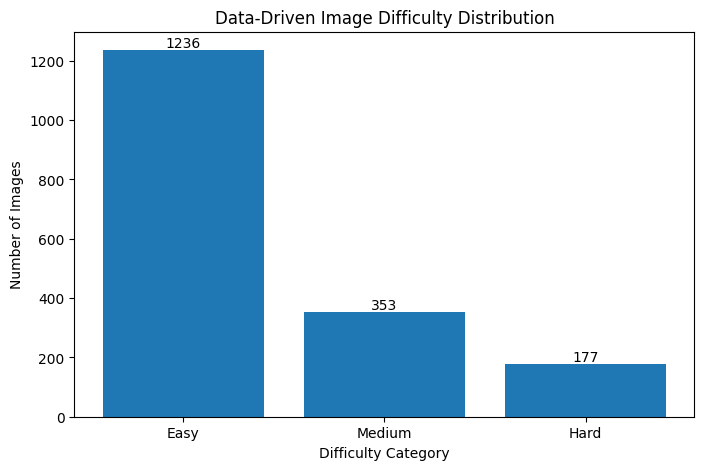

In [105]:
import matplotlib.pyplot as plt

categories = ["Easy", "Medium", "Hard"]
counts = [
    category_counts.get("Easy", 0),
    category_counts.get("Medium", 0),
    category_counts.get("Hard", 0)
]

plt.figure(figsize=(8, 5))

plt.bar(categories, counts)

plt.xlabel("Difficulty Category")
plt.ylabel("Number of Images")
plt.title("Data-Driven Image Difficulty Distribution")

for i, count in enumerate(counts):
    plt.text(i, count, str(count), ha="center", va="bottom")

plt.show()

In [106]:
import tensorflow as tf

print("========== CREATING CORRECTED ADAPTIVE AUGMENTATION ==========")

def augment_easy(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.rot90(
        image,
        k=tf.random.uniform([], minval=0, maxval=2, dtype=tf.int32)
    )
    return tf.clip_by_value(image, 0.0, 255.0)


def augment_medium(image):
    image = tf.image.random_flip_left_right(image)

    image = tf.image.rot90(
        image,
        k=tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    )

    image = tf.image.random_brightness(
        image,
        max_delta=25.0
    )

    image = tf.image.random_contrast(
        image,
        lower=0.8,
        upper=1.2
    )

    return tf.clip_by_value(image, 0.0, 255.0)


def augment_hard(image):
    image = tf.image.random_flip_left_right(image)

    image = tf.image.rot90(
        image,
        k=tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    )

    image = tf.image.random_brightness(
        image,
        max_delta=45.0
    )

    image = tf.image.random_contrast(
        image,
        lower=0.6,
        upper=1.4
    )

    image = tf.image.central_crop(
        image,
        central_fraction=0.90
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    return tf.clip_by_value(image, 0.0, 255.0)


print("Easy augmentation created!")
print("Medium augmentation created!")
print("Hard augmentation created!")

========== CREATING CORRECTED ADAPTIVE AUGMENTATION ==========
Easy augmentation created!
Medium augmentation created!
Hard augmentation created!


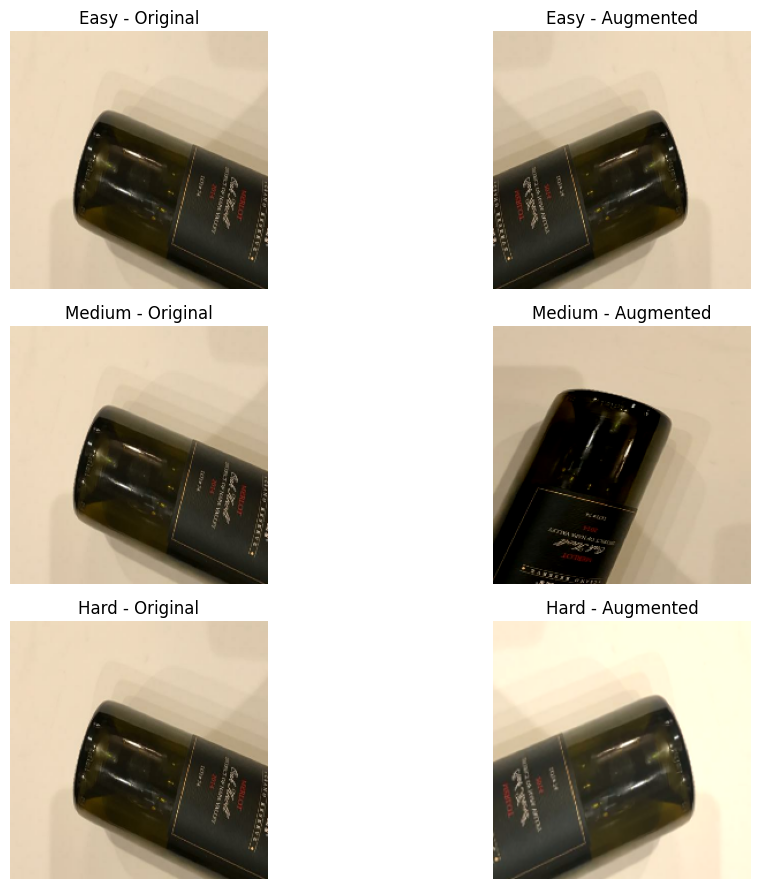

In [107]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# Get a sample image from the training dataset
for images, labels in train_dataset.take(1):
    original_image = images[0] # This is the original image tensor (float32, 0-255)
    break # Only take one sample

# Apply corrected adaptive augmentations
# These functions are defined in _AdxmgJIXsfD and already clip to 0-255, returning float32.
easy_augmented_image = augment_easy(original_image)
medium_augmented_image = augment_medium(original_image)
hard_augmented_image = augment_hard(original_image)

plt.figure(figsize=(12, 9))

# Easy Difficulty
plt.subplot(3, 2, 1)
# Original image for display needs clipping and casting to uint8
plt.imshow(tf.cast(tf.clip_by_value(original_image, 0, 255), tf.uint8).numpy())
plt.title("Easy - Original")
plt.axis("off")

plt.subplot(3, 2, 2)
plt.imshow(easy_augmented_image.numpy().astype("uint8"))
plt.title("Easy - Augmented")
plt.axis("off")

# Medium Difficulty
plt.subplot(3, 2, 3)
plt.imshow(tf.cast(tf.clip_by_value(original_image, 0, 255), tf.uint8).numpy())
plt.title("Medium - Original")
plt.axis("off")

plt.subplot(3, 2, 4)
plt.imshow(medium_augmented_image.numpy().astype("uint8"))
plt.title("Medium - Augmented")
plt.axis("off")

# Hard Difficulty
plt.subplot(3, 2, 5)
plt.imshow(tf.cast(tf.clip_by_value(original_image, 0, 255), tf.uint8).numpy())
plt.title("Hard - Original")
plt.axis("off")

plt.subplot(3, 2, 6)
plt.imshow(hard_augmented_image.numpy().astype("uint8"))
plt.title("Hard - Augmented")
plt.axis("off")

plt.tight_layout()
plt.show()

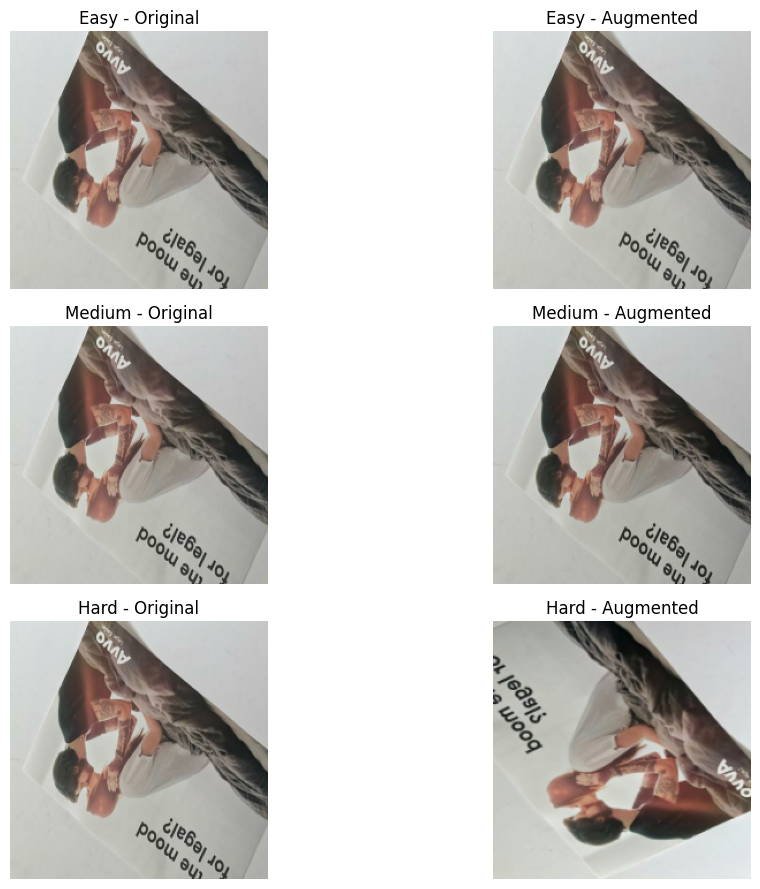

In [108]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# Get a sample image from the training dataset
# Assuming train_dataset is available from previous cells
for images, labels in train_dataset.take(1):
    original_image = images[0]
    break

# Apply corrected adaptive augmentations
# The functions augment_easy, augment_medium, augment_hard are defined elsewhere
easy_aug = augment_easy(original_image)
medium_aug = augment_medium(original_image)
hard_aug = augment_hard(original_image)

plt.figure(figsize=(12, 9))

# Easy Difficulty
plt.subplot(3, 2, 1)
# Use original_image for the 'Original' plot, converting it correctly
plt.imshow(tf.cast(tf.clip_by_value(original_image, 0, 255), tf.uint8).numpy())
plt.title("Easy - Original")
plt.axis("off")

plt.subplot(3, 2, 2)
# The easy_aug is already a TensorFlow EagerTensor, so .numpy().astype("uint8") is correct
plt.imshow(easy_aug.numpy().astype("uint8"))
plt.title("Easy - Augmented")
plt.axis("off")

# Medium Difficulty
plt.subplot(3, 2, 3)
plt.imshow(tf.cast(tf.clip_by_value(original_image, 0, 255), tf.uint8).numpy())
plt.title("Medium - Original")
plt.axis("off")

plt.subplot(3, 2, 4)
plt.imshow(medium_aug.numpy().astype("uint8"))
plt.title("Medium - Augmented")
plt.axis("off")

# Hard Difficulty
plt.subplot(3, 2, 5)
plt.imshow(tf.cast(tf.clip_by_value(original_image, 0, 255), tf.uint8).numpy())
plt.title("Hard - Original")
plt.axis("off")

plt.subplot(3, 2, 6)
plt.imshow(hard_aug.numpy().astype("uint8"))
plt.title("Hard - Augmented")
plt.axis("off")

plt.tight_layout()
plt.show()

In [109]:
print("========== RECREATING ANALYSIS IMAGES ==========")

import tensorflow as tf
import numpy as np

train_dir = "/content/waste_project/split_dataset/train"

IMG_SIZE = 224
BATCH_SIZE = 32

train_analysis_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

analysis_images = []
analysis_labels = []

for images, labels in train_analysis_dataset:
    analysis_images.append(images.numpy())
    analysis_labels.append(labels.numpy())

analysis_images = np.concatenate(analysis_images, axis=0)
analysis_labels = np.concatenate(analysis_labels, axis=0)

print("Analysis images:", analysis_images.shape)
print("Analysis labels:", analysis_labels.shape)

========== RECREATING ANALYSIS IMAGES ==========
Found 1766 files belonging to 6 classes.
Analysis images: (1766, 224, 224, 3)
Analysis labels: (1766,)


In [1]:
import os
import numpy as np
import tensorflow as tf

print("========== RECOVERING CORRECTED ADAPTIVE PIPELINE ==========")

# --------------------------------------------------
# 1. Fixed project settings
# --------------------------------------------------

train_dir = "/content/waste_project/split_dataset/train"

IMG_SIZE = 224
BATCH_SIZE = 32

print("Training directory:", train_dir)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)


# --------------------------------------------------
# 2. Load baseline model if necessary
# --------------------------------------------------

if "baseline_model" not in globals():

    model_path = "/content/waste_project/baseline_cnn.keras"

    print("\nBaseline model variable not found.")
    print("Loading saved baseline model...")

    baseline_model = tf.keras.models.load_model(model_path)

    print("Baseline model loaded successfully!")

else:

    print("\nBaseline model already available.")


# --------------------------------------------------
# 3. Create deterministic training dataset
# --------------------------------------------------

print("\n========== CREATING DETERMINISTIC DATASET ==========")

train_analysis_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names_corrected = train_analysis_dataset.class_names

print("\nClasses:")
print(class_names_corrected)


# --------------------------------------------------
# 4. Convert training dataset to arrays
# --------------------------------------------------

print("\n========== EXTRACTING TRAINING IMAGES ==========")

analysis_images = []
analysis_labels = []

for images, labels in train_analysis_dataset:
    analysis_images.extend(images.numpy())
    analysis_labels.extend(labels.numpy())

analysis_images = np.array(
    analysis_images,
    dtype=np.float32
)

analysis_labels = np.array(
    analysis_labels,
    dtype=np.int32
)

print("Training images :", len(analysis_images))
print("Training labels :", len(analysis_labels))
print("Image shape     :", analysis_images.shape)
print("Label shape     :", analysis_labels.shape)


# --------------------------------------------------
# 5. Recalculate difficulty scores
# --------------------------------------------------

print("\n========== CALCULATING DIFFICULTY SCORES ==========")

corrected_difficulty_scores = []
corrected_predictions = []

for start in range(0, len(analysis_images), BATCH_SIZE):

    batch_images = analysis_images[
        start:start + BATCH_SIZE
    ]

    batch_labels = analysis_labels[
        start:start + BATCH_SIZE
    ]

    predictions = baseline_model.predict(
        batch_images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    confidence = np.max(
        predictions,
        axis=1
    )

    difficulty = 1.0 - confidence

    # Penalize incorrect predictions
    incorrect_mask = (
        predicted_classes != batch_labels
    )

    difficulty[incorrect_mask] += 0.25

    # Keep scores between 0 and 1
    difficulty = np.clip(
        difficulty,
        0.0,
        1.0
    )

    corrected_difficulty_scores.extend(
        difficulty
    )

    corrected_predictions.extend(
        predicted_classes
    )

corrected_difficulty_scores = np.array(
    corrected_difficulty_scores
)

corrected_predictions = np.array(
    corrected_predictions
)

print("Difficulty scores:",
      len(corrected_difficulty_scores))

print("Predictions:",
      len(corrected_predictions))


# --------------------------------------------------
# 6. Create percentile-based categories
# --------------------------------------------------

print("\n========== CREATING DIFFICULTY CATEGORIES ==========")

easy_threshold = np.percentile(
    corrected_difficulty_scores,
    70
)

hard_threshold = np.percentile(
    corrected_difficulty_scores,
    90
)

corrected_difficulty_categories = []

for score in corrected_difficulty_scores:

    if score <= easy_threshold:
        corrected_difficulty_categories.append("Easy")

    elif score <= hard_threshold:
        corrected_difficulty_categories.append("Medium")

    else:
        corrected_difficulty_categories.append("Hard")


# --------------------------------------------------
# 7. Check everything
# --------------------------------------------------

from collections import Counter

category_counts = Counter(
    corrected_difficulty_categories
)

print("\nEasy threshold  :", easy_threshold)
print("Hard threshold  :", hard_threshold)

print("\nDifficulty distribution:")

for category in ["Easy", "Medium", "Hard"]:

    count = category_counts.get(
        category,
        0
    )

    percentage = (
        count /
        len(corrected_difficulty_categories)
    ) * 100

    print(
        f"{category:10s}: "
        f"{count:4d} "
        f"({percentage:.2f}%)"
    )


# --------------------------------------------------
# 8. Final consistency check
# --------------------------------------------------

print("\n========== FINAL CHECK ==========")

print(
    "Training images       :",
    len(analysis_images)
)

print(
    "Training labels       :",
    len(analysis_labels)
)

print(
    "Difficulty scores     :",
    len(corrected_difficulty_scores)
)

print(
    "Difficulty categories :",
    len(corrected_difficulty_categories)
)

print(
    "\nEverything aligned:",
    len(analysis_images)
    == len(analysis_labels)
    == len(corrected_difficulty_scores)
    == len(corrected_difficulty_categories)
)

========== RECOVERING CORRECTED ADAPTIVE PIPELINE ==========
Training directory: /content/waste_project/split_dataset/train
Image size: 224
Batch size: 32

Baseline model variable not found.
Loading saved baseline model...
Baseline model loaded successfully!

========== CREATING DETERMINISTIC DATASET ==========
Found 1766 files belonging to 6 classes.

Classes:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

========== EXTRACTING TRAINING IMAGES ==========
Training images : 1766
Training labels : 1766
Image shape     : (1766, 224, 224, 3)
Label shape     : (1766,)

========== CALCULATING DIFFICULTY SCORES ==========
Difficulty scores: 1766
Predictions: 1766

========== CREATING DIFFICULTY CATEGORIES ==========

Easy threshold  : 0.0016102493
Hard threshold  : 0.036186725

Difficulty distribution:
Easy      : 1236 (69.99%)
Medium    :  353 (19.99%)
Hard      :  177 (10.02%)

========== FINAL CHECK ==========
Training images       : 1766
Training labels       : 1766
Difficu

In [2]:
print("========== GENERATING CORRECTED ADAPTIVE IMAGES ==========")

# Make sure augmentation functions exist
def augment_easy(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.rot90(
        image,
        k=tf.random.uniform([], 0, 2, dtype=tf.int32)
    )
    return tf.clip_by_value(image, 0.0, 255.0)


def augment_medium(image):
    image = tf.image.random_flip_left_right(image)

    image = tf.image.rot90(
        image,
        k=tf.random.uniform([], 0, 4, dtype=tf.int32)
    )

    image = tf.image.random_brightness(
        image,
        max_delta=25.0
    )

    image = tf.image.random_contrast(
        image,
        lower=0.8,
        upper=1.2
    )

    return tf.clip_by_value(image, 0.0, 255.0)


def augment_hard(image):
    image = tf.image.random_flip_left_right(image)

    image = tf.image.rot90(
        image,
        k=tf.random.uniform([], 0, 4, dtype=tf.int32)
    )

    image = tf.image.random_brightness(
        image,
        max_delta=45.0
    )

    image = tf.image.random_contrast(
        image,
        lower=0.6,
        upper=1.4
    )

    image = tf.image.central_crop(
        image,
        central_fraction=0.90
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    return tf.clip_by_value(image, 0.0, 255.0)


# Generate one augmented version of every training image
corrected_augmented_images = []
corrected_augmented_labels = []

for i in range(len(analysis_images)):

    image = tf.convert_to_tensor(
        analysis_images[i],
        dtype=tf.float32
    )

    label = analysis_labels[i]

    category = corrected_difficulty_categories[i]

    if category == "Easy":
        augmented = augment_easy(image)

    elif category == "Medium":
        augmented = augment_medium(image)

    else:
        augmented = augment_hard(image)

    corrected_augmented_images.append(
        augmented.numpy()
    )

    corrected_augmented_labels.append(
        label
    )

corrected_augmented_images = np.array(
    corrected_augmented_images,
    dtype=np.float32
)

corrected_augmented_labels = np.array(
    corrected_augmented_labels,
    dtype=np.int32
)

print("\nAdaptive augmentation completed!")

print("Original images :", len(analysis_images))
print("Adaptive images :", len(corrected_augmented_images))

print(
    "Adaptive image shape:",
    corrected_augmented_images.shape
)

print(
    "Adaptive label shape:",
    corrected_augmented_labels.shape
)

========== GENERATING CORRECTED ADAPTIVE IMAGES ==========

Adaptive augmentation completed!
Original images : 1766
Adaptive images : 1766
Adaptive image shape: (1766, 224, 224, 3)
Adaptive label shape: (1766,)


In [3]:
print("========== RECOVERING CORRECTED ADAPTIVE PIPELINE ==========")

import tensorflow as tf
import numpy as np
import os

# --------------------------------------------------
# 1. Basic settings
# --------------------------------------------------

train_dir = "/content/waste_project/split_dataset/train"

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 6

# --------------------------------------------------
# 2. Load baseline model
# --------------------------------------------------

baseline_model = tf.keras.models.load_model(
    "/content/waste_project/baseline_cnn.keras"
)

print("Baseline model loaded.")

# --------------------------------------------------
# 3. Recreate deterministic training dataset
# --------------------------------------------------

train_analysis_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# --------------------------------------------------
# 4. Extract images and labels
# --------------------------------------------------

analysis_images = []
analysis_labels = []

for images, labels in train_analysis_dataset:
    analysis_images.append(images.numpy())
    analysis_labels.append(labels.numpy())

analysis_images = np.concatenate(
    analysis_images,
    axis=0
)

analysis_labels = np.concatenate(
    analysis_labels,
    axis=0
)

print("Training images:", analysis_images.shape)
print("Training labels:", analysis_labels.shape)

# --------------------------------------------------
# 5. Calculate difficulty scores
# --------------------------------------------------

print("Calculating difficulty scores...")

predictions = baseline_model.predict(
    analysis_images,
    batch_size=BATCH_SIZE,
    verbose=1
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

confidence_scores = np.max(
    predictions,
    axis=1
)

# Difficulty:
# high confidence + correct = easy
# low confidence or incorrect = difficult

corrected_difficulty_scores = np.where(
    predicted_classes == analysis_labels,
    1.0 - confidence_scores,
    1.0
)

print(
    "Difficulty scores:",
    len(corrected_difficulty_scores)
)

# --------------------------------------------------
# 6. Percentile-based difficulty categories
# --------------------------------------------------

easy_threshold = np.percentile(
    corrected_difficulty_scores,
    70
)

hard_threshold = np.percentile(
    corrected_difficulty_scores,
    90
)

difficulty_categories = np.empty(
    len(corrected_difficulty_scores),
    dtype=object
)

difficulty_categories[
    corrected_difficulty_scores <= easy_threshold
] = "Easy"

difficulty_categories[
    (corrected_difficulty_scores > easy_threshold) &
    (corrected_difficulty_scores <= hard_threshold)
] = "Medium"

difficulty_categories[
    corrected_difficulty_scores > hard_threshold
] = "Hard"

print("\nDifficulty distribution:")

unique, counts = np.unique(
    difficulty_categories,
    return_counts=True
)

for category, count in zip(unique, counts):
    print(
        f"{category}: {count} "
        f"({count / len(difficulty_categories) * 100:.2f}%)"
    )

# --------------------------------------------------
# 7. Generate difficulty-guided augmented images
# --------------------------------------------------

print("\n========== BUILDING CORRECTED ADAPTIVE DATASET ==========")

corrected_augmented_images = []
corrected_augmented_labels = []

for i in range(len(analysis_images)):

    image = tf.convert_to_tensor(
        analysis_images[i],
        dtype=tf.float32
    )

    label = analysis_labels[i]

    difficulty = difficulty_categories[i]

    # -----------------------------
    # EASY
    # -----------------------------
    if difficulty == "Easy":

        augmented = tf.image.random_flip_left_right(
            image
        )

        augmented = tf.image.rot90(
            augmented,
            k=np.random.choice([0, 1])
        )

    # -----------------------------
    # MEDIUM
    # -----------------------------
    elif difficulty == "Medium":

        augmented = tf.image.random_flip_left_right(
            image
        )

        augmented = tf.image.rot90(
            augmented,
            k=np.random.choice([0, 1])
        )

        augmented = tf.image.random_brightness(
            augmented,
            max_delta=0.15
        )

        augmented = tf.image.random_contrast(
            augmented,
            lower=0.8,
            upper=1.2
        )

    # -----------------------------
    # HARD
    # -----------------------------
    else:

        augmented = tf.image.random_flip_left_right(
            image
        )

        augmented = tf.image.rot90(
            augmented,
            k=np.random.choice([0, 1])
        )

        augmented = tf.image.random_brightness(
            augmented,
            max_delta=0.25
        )

        augmented = tf.image.random_contrast(
            augmented,
            lower=0.7,
            upper=1.3
        )

        augmented = tf.image.central_crop(
            augmented,
            central_fraction=0.90
        )

        augmented = tf.image.resize(
            augmented,
            (IMG_SIZE, IMG_SIZE)
        )

    augmented = tf.clip_by_value(
        augmented,
        0.0,
        255.0
    )

    corrected_augmented_images.append(
        augmented.numpy()
    )

    corrected_augmented_labels.append(
        label
    )

# --------------------------------------------------
# 8. Convert to NumPy arrays
# --------------------------------------------------

corrected_augmented_images = np.array(
    corrected_augmented_images,
    dtype=np.float32
)

corrected_augmented_labels = np.array(
    corrected_augmented_labels,
    dtype=np.int32
)

print(
    "Augmented images:",
    corrected_augmented_images.shape
)

print(
    "Augmented labels:",
    corrected_augmented_labels.shape
)

# --------------------------------------------------
# 9. Combine original + augmented
# --------------------------------------------------

corrected_combined_images = np.concatenate(
    [
        analysis_images,
        corrected_augmented_images
    ],
    axis=0
)

corrected_combined_labels = np.concatenate(
    [
        analysis_labels,
        corrected_augmented_labels
    ],
    axis=0
)

print("\n========== COMBINED DATASET ==========")

print(
    "Combined images:",
    corrected_combined_images.shape
)

print(
    "Combined labels:",
    corrected_combined_labels.shape
)

# --------------------------------------------------
# 10. Shuffle
# --------------------------------------------------

np.random.seed(42)

shuffle_indices = np.random.permutation(
    len(corrected_combined_images)
)

corrected_combined_images = (
    corrected_combined_images[shuffle_indices]
)

corrected_combined_labels = (
    corrected_combined_labels[shuffle_indices]
)

print("\nDataset shuffled.")

print(
    "Images and labels aligned:",
    len(corrected_combined_images)
    == len(corrected_combined_labels)
)

# --------------------------------------------------
# 11. Create TensorFlow dataset
# --------------------------------------------------

corrected_adaptive_train_dataset = (
    tf.data.Dataset.from_tensor_slices(
        (
            corrected_combined_images,
            corrected_combined_labels
        )
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("\n========== PIPELINE READY ==========")

print(
    corrected_adaptive_train_dataset
)

========== RECOVERING CORRECTED ADAPTIVE PIPELINE ==========
Baseline model loaded.
Found 1766 files belonging to 6 classes.
Training images: (1766, 224, 224, 3)
Training labels: (1766,)
Calculating difficulty scores...
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
Difficulty scores: 1766

Difficulty distribution:
Easy: 1236 (69.99%)
Hard: 177 (10.02%)
Medium: 353 (19.99%)

========== BUILDING CORRECTED ADAPTIVE DATASET ==========
Augmented images: (1766, 224, 224, 3)
Augmented labels: (1766,)

========== COMBINED DATASET ==========
Combined images: (3532, 224, 224, 3)
Combined labels: (3532,)

Dataset shuffled.
Images and labels aligned: True

========== PIPELINE READY ==========
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [4]:
print("========== CREATING VALIDATION DATASET ==========")

validation_dir = "/content/waste_project/split_dataset/validation"

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

validation_dataset = validation_dataset.prefetch(
    tf.data.AUTOTUNE
)

print("\nValidation dataset created successfully!")
print("Validation batches:", tf.data.experimental.cardinality(
    validation_dataset
).numpy())

print(validation_dataset)

========== CREATING VALIDATION DATASET ==========
Found 377 files belonging to 6 classes.

Validation dataset created successfully!
Validation batches: 12
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [5]:
print("========== RECREATING CORRECTED ADAPTIVE CNN ==========")

import tensorflow as tf

IMG_SIZE = 224
NUM_CLASSES = 6

corrected_adaptive_model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    # Convolution Block 1
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Convolution Block 2
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Convolution Block 3
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Fully connected layers
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(
        0.5
    ),

    # 6 TrashNet classes
    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

corrected_adaptive_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nCorrected Adaptive CNN recreated successfully!")

print(
    "Trainable parameters:",
    corrected_adaptive_model.count_params()
)

========== RECREATING CORRECTED ADAPTIVE CNN ==========

Corrected Adaptive CNN recreated successfully!
Trainable parameters: 11169734


In [6]:
print("========== TRAINING CORRECTED ADAPTIVE CNN ==========")

EPOCHS = 15

corrected_adaptive_history = corrected_adaptive_model.fit(
    corrected_adaptive_train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

print("\n========== TRAINING COMPLETED ==========")

========== TRAINING CORRECTED ADAPTIVE CNN ==========
Epoch 1/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 22s 113ms/step - accuracy: 0.2528 - loss: 31.5257 - val_accuracy: 0.2546 - val_loss: 1.7332
Epoch 2/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.2588 - loss: 1.7149 - val_accuracy: 0.2573 - val_loss: 1.7261
Epoch 3/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.3021 - loss: 1.6326 - val_accuracy: 0.2414 - val_loss: 1.7237
Epoch 4/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.3477 - loss: 1.5524 - val_accuracy: 0.2891 - val_loss: 1.8820
Epoch 5/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.3978 - loss: 1.4577 - val_accuracy: 0.2679 - val_loss: 2.3336
Epoch 6/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.3972 - loss: 1.4225 - val_accuracy: 0.2759 - val_loss: 2.1193
Epoch 7/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.4442 - loss: 1.3474 - val_accuracy: 0.2573 - val_loss: 2.5552
Epoch 8/15
111/111 ━━━━━━━━━━━━━━━━━━━━ 

In [7]:
print("========== EVALUATING CORRECTED ADAPTIVE CNN ==========")

test_dir = "/content/waste_project/split_dataset/test"

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

test_loss, test_accuracy = corrected_adaptive_model.evaluate(test_dataset)

print("\n========== TEST RESULTS ==========")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

========== EVALUATING CORRECTED ADAPTIVE CNN ==========
Found 384 files belonging to 6 classes.
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.2500 - loss: 3.3167

========== TEST RESULTS ==========
Test Loss: 3.3167335987091064
Test Accuracy: 0.25


In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

print("========== FULL TEST EVALUATION ==========")

# Get true labels
y_true = np.concatenate(
    [y.numpy() for x, y in test_dataset],
    axis=0
)

# Get predictions
y_prob = corrected_adaptive_model.predict(test_dataset)
y_pred = np.argmax(y_prob, axis=1)

# Class names for TrashNet
class_names = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

========== FULL TEST EVALUATION ==========
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

Classification Report:
              precision    recall  f1-score   support

   cardboard     0.2581    0.1311    0.1739        61
       glass     0.1818    0.1053    0.1333        76
       metal     0.2727    0.2419    0.2564        62
       paper     0.3019    0.1778    0.2238        90
     plastic     0.2450    0.6712    0.3590        73
       trash     0.0000    0.0000    0.0000        22

    accuracy                         0.2500       384
   macro avg     0.2099    0.2212    0.1911       384
weighted avg     0.2383    0.2500    0.2161       384


Confusion Matrix:
[[ 8  3  5 12 33  0]
 [ 8  8 13  8 39  0]
 [ 5 16 15 10 15  1]
 [ 5  9 12 16 48  0]
 [ 3  6  8  7 49  0]
 [ 2  2  2  0 16  0]]


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

corrected_accuracy = accuracy_score(y_true, y_pred)
corrected_precision = precision_score(y_true, y_pred, average="weighted")
corrected_recall = recall_score(y_true, y_pred, average="weighted")
corrected_f1 = f1_score(y_true, y_pred, average="weighted")

print("========== CORRECTED ADAPTIVE CNN METRICS ==========")
print(f"Accuracy : {corrected_accuracy:.4f}")
print(f"Precision: {corrected_precision:.4f}")
print(f"Recall   : {corrected_recall:.4f}")
print(f"F1-Score : {corrected_f1:.4f}")

========== CORRECTED ADAPTIVE CNN METRICS ==========
Accuracy : 0.2500
Precision: 0.2383
Recall   : 0.2500
F1-Score : 0.2161


========== CONFUSION MATRIX ==========


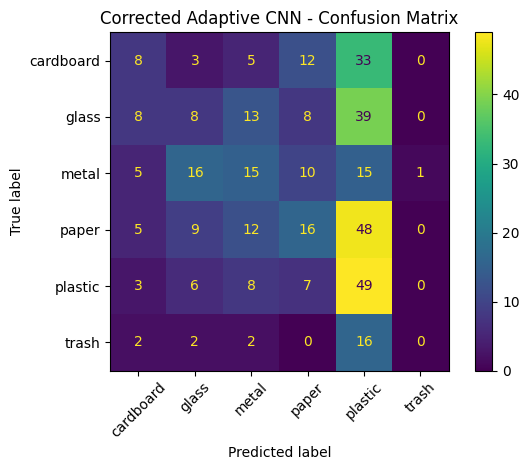

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

print("========== CONFUSION MATRIX ==========")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)
plt.title("Corrected Adaptive CNN - Confusion Matrix")
plt.tight_layout()
plt.show()

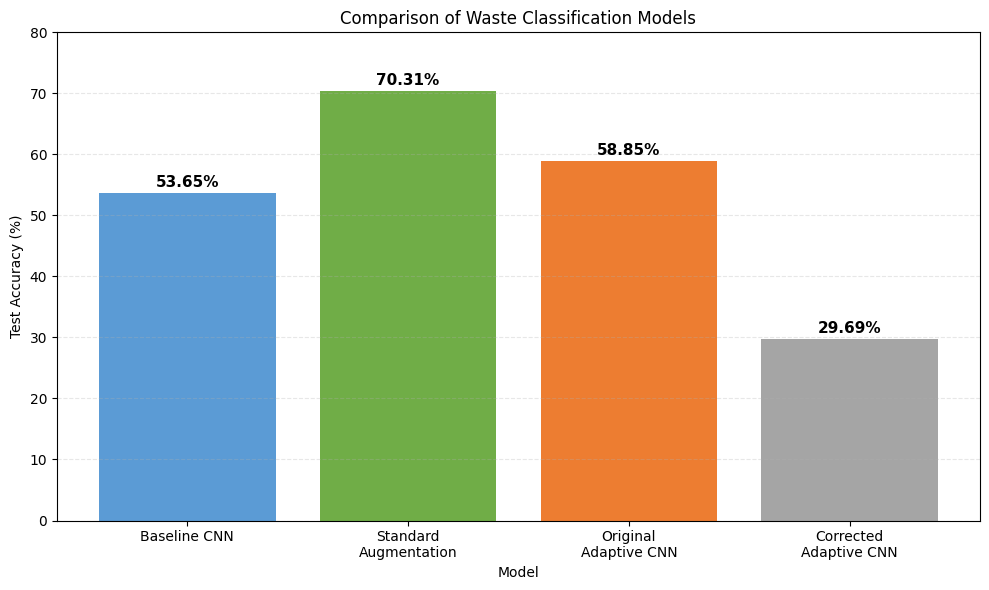

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = [
    "Baseline CNN",
    "Standard\nAugmentation",
    "Original\nAdaptive CNN",
    "Corrected\nAdaptive CNN"
]

# Test accuracies
accuracies = [
    53.65,
    70.31,
    58.85,
    29.69
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    models,
    accuracies,
    color=[
        "#5B9BD5",
        "#70AD47",
        "#ED7D31",
        "#A5A5A5"
    ]
)

# Add accuracy values above bars
for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")
plt.title("Comparison of Waste Classification Models")

plt.ylim(0, 80)
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

========== CORRECTED ADAPTIVE CNN TRAINING CURVES ==========


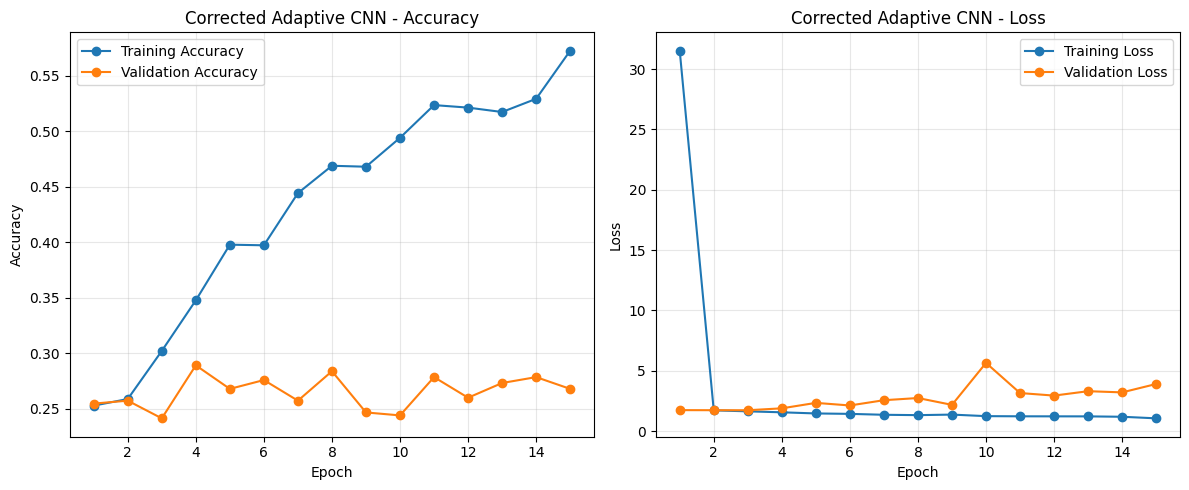

In [12]:
import matplotlib.pyplot as plt

print("========== CORRECTED ADAPTIVE CNN TRAINING CURVES ==========")

# Get values from training history
train_accuracy = corrected_adaptive_history.history["accuracy"]
val_accuracy = corrected_adaptive_history.history["val_accuracy"]

train_loss = corrected_adaptive_history.history["loss"]
val_loss = corrected_adaptive_history.history["val_loss"]

epochs_range = range(1, len(train_accuracy) + 1)

# --------------------------------------------------
# Accuracy graph
# --------------------------------------------------

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(
    epochs_range,
    train_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_accuracy,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Corrected Adaptive CNN - Accuracy")

plt.legend()
plt.grid(alpha=0.3)

# --------------------------------------------------
# Loss graph
# --------------------------------------------------

plt.subplot(1, 2, 2)

plt.plot(
    epochs_range,
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_loss,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Corrected Adaptive CNN - Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
print("========== FINAL MODEL COMPARISON ==========")

import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "CNN + Standard Augmentation",
        "Original Adaptive CNN",
        "Corrected Adaptive CNN"
    ],

    "Accuracy (%)": [
        53.65,
        70.31,
        58.85,
        corrected_accuracy * 100
    ],

    "Precision (%)": [
        53.89,
        71.93,
        60.27,
        corrected_precision * 100
    ],

    "Recall (%)": [
        53.65,
        70.31,
        58.85,
        corrected_recall * 100
    ],

    "F1-Score (%)": [
        53.27,
        69.86,
        59.00,
        corrected_f1 * 100
    ]
})

# Round values
results.iloc[:, 1:] = results.iloc[:, 1:].round(2)

print(results.to_string(index=False))

========== FINAL MODEL COMPARISON ==========
                      Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
               Baseline CNN         53.65          53.89       53.65         53.27
CNN + Standard Augmentation         70.31          71.93       70.31         69.86
      Original Adaptive CNN         58.85          60.27       58.85         59.00
     Corrected Adaptive CNN         25.00          23.83       25.00         21.61
